# Null Space Analysis

This notebook will extract and analyze neuron spiking data from NWB files.


In [125]:
import os
from pathlib import Path
from pynwb import NWBHDF5IO
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Set up paths
data_root = Path("/Users/jundazhu/SBCAT/000673")


## All Functions

All functions are defined below, organized by category:
- **Trial Selection**: Select trials by load, correctness, probe in/out, or indices
- **File Listing**: List and select NWB files
- **Data Extraction**: Extract spike data and trial information from NWB files
- **DataFrame Creation**: Convert extraction results to DataFrames
- **Spike Segmentation**: Segment spikes by trials, aligned to specific events
- **Workflow**: Process single or multiple sessions

In [126]:
def select_trials_by_load(trials_df, load_values):
    """
    Select trials by memory load values (session-level).
    
    Args:
        trials_df: DataFrame with trial information for a session
        load_values: Single load value (int) or list of load values (e.g., [1, 3])
    
    Returns:
        selected_trials_df: Filtered DataFrame with selected trials
        selected_indices: Array of trial indices (0-based) in original trials_df
    
    Note: Works at session level - select trials once per session, use for all units in that session.
    """
    if 'loads' not in trials_df.columns:
        raise ValueError("trials_df must have a 'loads' column")
    
    if not isinstance(load_values, (list, tuple, np.ndarray)):
        load_values = [load_values]
    
    mask = trials_df['loads'].isin(load_values)
    selected_indices = np.where(mask)[0]
    selected_trials_df = trials_df.iloc[selected_indices].copy()
    
    return selected_trials_df, selected_indices


def select_trials_by_correctness(trials_df, correct_only=True):
    """
    Select trials by correctness (session-level).
    
    Args:
        trials_df: DataFrame with trial information for a session
        correct_only: If True, select only correct trials. If False, select only incorrect trials.
    
    Returns:
        selected_trials_df: Filtered DataFrame with selected trials
        selected_indices: Array of trial indices (0-based) in original trials_df
    
    Note: Works at session level - select trials once per session, use for all units in that session.
    """
    if 'response_accuracy' not in trials_df.columns:
        raise ValueError("trials_df must have a 'response_accuracy' column")
    
    if correct_only:
        mask = (trials_df['response_accuracy'] == 1)
    else:
        mask = (trials_df['response_accuracy'] != 1)
    
    selected_indices = np.where(mask)[0]
    selected_trials_df = trials_df.iloc[selected_indices].copy()
    
    return selected_trials_df, selected_indices


def select_trials_by_probe_in_out(trials_df, probe_in_out):
    """
    Select trials by probe in/out status (session-level).
    
    Args:
        trials_df: DataFrame with trial information for a session
        probe_in_out: 'in' or 'out' to select probe in set or probe out set
    
    Returns:
        selected_trials_df: Filtered DataFrame with selected trials
        selected_indices: Array of trial indices (0-based) in original trials_df
    
    Note: Works at session level - select trials once per session, use for all units in that session.
    """
    if 'probe_in_out' not in trials_df.columns:
        raise ValueError("trials_df must have a 'probe_in_out' column")
    
    mask = (trials_df['probe_in_out'] == probe_in_out)
    selected_indices = np.where(mask)[0]
    selected_trials_df = trials_df.iloc[selected_indices].copy()
    
    return selected_trials_df, selected_indices


def select_trials_by_indices(trials_df, trial_indices):
    """
    Select trials by explicit trial indices (session-level).
    
    Args:
        trials_df: DataFrame with trial information for a session
        trial_indices: List/array of trial indices to select (0-based)
    
    Returns:
        selected_trials_df: Filtered DataFrame with selected trials
        selected_indices: Array of trial indices (0-based) in original trials_df
    
    Note: Works at session level - select trials once per session, use for all units in that session.
    """
    selected_indices = np.array(trial_indices)
    selected_trials_df = trials_df.iloc[selected_indices].copy()
    return selected_trials_df, selected_indices


# ============================================================================
# File Listing Functions
# ============================================================================

def list_available_files(data_dir):
    """List all available NWB files with indices for selection."""
    files = sorted(data_dir.rglob("*.nwb"))
    print(f"Found {len(files)} NWB files:\n")
    for i, f in enumerate(files):
        rel_path = f.relative_to(data_dir)
        print(f"{i:3d}. {rel_path}")
    return files


# ============================================================================
# Data Extraction Functions
# ============================================================================

def extract_spike_data(filepath, include_waveforms=False, quality_filters=None, include_trials=True):
    """
    Extract spike data from a single NWB file.
    
    Args:
        filepath: Path to NWB file
        include_waveforms: If True, include spike waveforms (memory intensive)
        quality_filters: Dict with quality filter criteria, e.g.:
            {'min_snr': 1.0, 'min_isolation_distance': 5.0}
        include_trials: If True, extract trial information
    
    Returns:
        dict with keys:
            - 'filepath': Path to source file
            - 'subject_id': Subject ID extracted from filename
            - 'session_id': Session ID extracted from filename
            - 'units': List of dicts, each containing unit data
            - 'trials': DataFrame with trial information (if include_trials=True)
    """
    filepath = Path(filepath)
    
    # Extract subject and session from filename
    parts = filepath.stem.split('_')
    subject_id = None
    session_id = None
    for part in parts:
        if part.startswith('sub-'):
            subject_id = int(part.split('-')[1])
        elif part.startswith('ses-'):
            session_id = int(part.split('-')[1])
    
    result = {
        'filepath': str(filepath),
        'subject_id': subject_id,
        'session_id': session_id,
        'units': []
    }
    
    try:
        with NWBHDF5IO(str(filepath), mode="r", load_namespaces=True) as io:
            nwbf = io.read()
            
            # Extract trials
            if include_trials and nwbf.trials is not None:
                try:
                    trials_df = nwbf.trials.to_dataframe()
                    result['trials'] = trials_df
                except Exception as e:
                    print(f"Warning: Could not extract trials from {filepath.name}: {e}")
                    result['trials'] = None
            else:
                result['trials'] = None
            
            if nwbf.units is None:
                print(f"Warning: No units found in {filepath.name}")
                return result
            
            # Get units table
            units_df = nwbf.units.to_dataframe()
            electrodes_df = nwbf.electrodes.to_dataframe() if nwbf.electrodes is not None else None
            
            # Extract data for each unit
            for unit_idx in units_df.index:
                unit_data = {
                    'unit_id': int(unit_idx),
                    'spike_times': None,
                    'electrode_idx': None,
                    'cluster_id': None,
                    'mean_snr': None,
                    'peak_snr': None,
                    'isolation_distance': None,
                    'mean_proj_dist': None,
                    'n_spikes': 0,
                    'brain_region': None
                }
                
                # Extract spike times
                try:
                    spike_times = np.array(nwbf.units['spike_times'][unit_idx][:])
                    unit_data['spike_times'] = spike_times
                    unit_data['n_spikes'] = len(spike_times)
                except Exception as e:
                    print(f"Warning: Could not extract spike times for unit {unit_idx}: {e}")
                    continue
                
                # Extract electrode information
                if 'electrodes' in units_df.columns:
                    try:
                        electrode_info = units_df.loc[unit_idx, 'electrodes']
                        # Electrode info might be a table or index
                        if hasattr(electrode_info, 'index'):
                            unit_data['electrode_idx'] = int(electrode_info.index[0]) if len(electrode_info.index) > 0 else None
                        else:
                            unit_data['electrode_idx'] = int(electrode_info) if pd.notna(electrode_info) else None
                        
                        # Get brain region from electrode
                        if unit_data['electrode_idx'] is not None and electrodes_df is not None:
                            if 'location' in electrodes_df.columns:
                                unit_data['brain_region'] = electrodes_df.loc[unit_data['electrode_idx'], 'location']
                    except Exception as e:
                        pass  # Electrode info might not be available
                
                # Extract quality metrics
                if 'clusterID_orig' in units_df.columns:
                    unit_data['cluster_id'] = units_df.loc[unit_idx, 'clusterID_orig']
                if 'waveforms_mean_snr' in units_df.columns:
                    unit_data['mean_snr'] = units_df.loc[unit_idx, 'waveforms_mean_snr']
                if 'waveforms_peak_snr' in units_df.columns:
                    unit_data['peak_snr'] = units_df.loc[unit_idx, 'waveforms_peak_snr']
                if 'waveforms_isolation_distance' in units_df.columns:
                    unit_data['isolation_distance'] = units_df.loc[unit_idx, 'waveforms_isolation_distance']
                if 'waveforms_mean_proj_dist' in units_df.columns:
                    unit_data['mean_proj_dist'] = units_df.loc[unit_idx, 'waveforms_mean_proj_dist']
                
                # Apply quality filters
                if quality_filters is not None:
                    skip_unit = False
                    if 'min_snr' in quality_filters and unit_data['mean_snr'] is not None:
                        if unit_data['mean_snr'] < quality_filters['min_snr']:
                            skip_unit = True
                    if 'min_isolation_distance' in quality_filters and unit_data['isolation_distance'] is not None:
                        if unit_data['isolation_distance'] < quality_filters['min_isolation_distance']:
                            skip_unit = True
                    if 'min_n_spikes' in quality_filters:
                        if unit_data['n_spikes'] < quality_filters['min_n_spikes']:
                            skip_unit = True
                    if skip_unit:
                        continue
                
                # Extract waveforms if requested
                if include_waveforms and 'waveforms' in units_df.columns:
                    try:
                        waveforms = np.array(nwbf.units['waveforms'][unit_idx][:])
                        unit_data['waveforms'] = waveforms
                    except Exception as e:
                        pass  # Waveforms might not be available
                
                result['units'].append(unit_data)
    
    except Exception as e:
        print(f"Error processing {filepath.name}: {e}")
        import traceback
        traceback.print_exc()
    
    return result


def batch_extract_spike_data(filepaths, include_waveforms=False, quality_filters=None, include_trials=True, verbose=True):
    """
    Extract spike data from multiple NWB files in batch.
    
    Args:
        filepaths: List of NWB file paths or single path
        include_waveforms: If True, include spike waveforms
        quality_filters: Dict with quality filter criteria
        include_trials: If True, extract trial information
        verbose: If True, print progress
    
    Returns:
        List of extraction results (one per file)
    """
    if isinstance(filepaths, (str, Path)):
        filepaths = [filepaths]
    
    results = []
    n_files = len(filepaths)
    
    for i, filepath in enumerate(filepaths, 1):
        if verbose:
            print(f"Processing file {i}/{n_files}: {Path(filepath).name}")
        
        result = extract_spike_data(
            filepath, 
            include_waveforms=include_waveforms,
            quality_filters=quality_filters,
            include_trials=include_trials
        )
        results.append(result)
        
        if verbose:
            n_units = len(result['units'])
            n_trials = len(result['trials']) if result['trials'] is not None else 0
            print(f"  Extracted {n_units} units, {n_trials} trials")
    
    return results


# ============================================================================
# DataFrame Creation Functions
# ============================================================================

def create_spike_dataframe(extraction_results):
    """
    Convert extraction results to a pandas DataFrame for easy analysis.
    
    Args:
        extraction_results: List of extraction result dicts
    
    Returns:
        DataFrame with one row per unit
    """
    rows = []
    
    for result in extraction_results:
        for unit in result['units']:
            row = {
                'subject_id': result['subject_id'],
                'session_id': result['session_id'],
                'filepath': result['filepath'],
                'unit_id': unit['unit_id'],
                'n_spikes': unit['n_spikes'],
                'electrode_idx': unit['electrode_idx'],
                'brain_region': unit['brain_region'],
                'cluster_id': unit['cluster_id'],
                'mean_snr': unit['mean_snr'],
                'peak_snr': unit['peak_snr'],
                'isolation_distance': unit['isolation_distance'],
                'mean_proj_dist': unit['mean_proj_dist'],
                'spike_times': unit['spike_times']  # Keep as array
            }
            rows.append(row)
    
    return pd.DataFrame(rows)


def extract_trials_dataframe(extraction_results):
    """
    Extract trial information from extraction results.
    
    Args:
        extraction_results: List of extraction result dicts
    
    Returns:
        DataFrame with trial information, including subject/session identifiers
    """
    trial_rows = []
    
    for result in extraction_results:
        if result['trials'] is not None:
            trials_df = result['trials'].copy()
            trials_df['subject_id'] = result['subject_id']
            trials_df['session_id'] = result['session_id']
            trials_df['filepath'] = result['filepath']
            trial_rows.append(trials_df)
    
    if len(trial_rows) == 0:
        return pd.DataFrame()
    
    return pd.concat(trial_rows, ignore_index=True)


# ============================================================================
# Spike Segmentation Functions
# ============================================================================

def segment_spikes_by_trials(spike_times, trials_df, align_to='start_time', time_window=None):
    """
    Segment spikes by trials, aligned to a specific event timestamp.

    Args:
        spike_times: Array of spike timestamps (seconds)
        trials_df: DataFrame with trial information
        align_to: Column name in trials_df to align to:
                  - 'start_time': Trial start (default)
                  - 'timestamps_Probe': Probe onset
                  - 'timestamps_Encoding1': First encoding start
                  - 'timestamps_Maintenance': Maintenance start
                  - 'timestamps_Response': Response time
        time_window: Tuple (start_offset, end_offset) relative to alignment point in seconds.
                     If None, uses full trial (start_time to stop_time)

    Returns:
        List of arrays, one per trial, containing aligned spike times
    """
    segmented_spikes = []

    for trial_idx, trial in trials_df.iterrows():
        # Get alignment point
        if align_to in trial and pd.notna(trial[align_to]) and trial[align_to] > 0:
            alignment_point = trial[align_to]
        elif 'start_time' in trial:
            alignment_point = trial['start_time']
        else:
            segmented_spikes.append(np.array([]))
            continue

        # Determine time window
        if time_window is not None:
            window_start = alignment_point + time_window[0]
            window_end = alignment_point + time_window[1]
        else:
            # Use full trial
            window_start = trial.get('start_time', alignment_point)
            window_end = trial.get('stop_time', alignment_point + 10.0)  # Default 10s if no stop_time

        # Extract spikes in this window
        mask = (spike_times >= window_start) & (spike_times < window_end)
        trial_spikes = spike_times[mask]

        # Align spikes to alignment point
        aligned_spikes = trial_spikes - alignment_point

        segmented_spikes.append(aligned_spikes)

    return segmented_spikes


def segment_spikes_by_selected_trials(spike_times, trials_df, selected_trial_indices=None,
                                      align_to='start_time', time_window=None):
    """
    Segment spikes by selected trials, aligned to a specific event.

    Args:
        spike_times: Array of spike timestamps
        trials_df: DataFrame with trial information
        selected_trial_indices: Array/list of trial indices to use (0-based).
                               If None, uses all trials.
        align_to: Column name in trials_df to align to (e.g., 'timestamps_Probe', 'start_time')
        time_window: Tuple (start_offset, end_offset) relative to alignment point

    Returns:
        List of arrays, one per selected trial, containing aligned spike times
    """
    if selected_trial_indices is not None:
        selected_trials_df = trials_df.iloc[selected_trial_indices].copy()
        selected_trials_df = selected_trials_df.reset_index(drop=True)
    else:
        selected_trials_df = trials_df

    return segment_spikes_by_trials(
        spike_times,
        selected_trials_df,
        align_to=align_to,
        time_window=time_window
    )


# ============================================================================
# Workflow Functions
# ============================================================================

def process_session(filepath, selected_trial_indices=None, align_to='start_time', time_window=None):
    """
    Process a single session: extract units, select trials, segment spikes.
    
    Args:
        filepath: Path to NWB file
        selected_trial_indices: Array/list of trial indices to use (0-based) for this session.
                               If None, uses all trials.
        align_to: Column name in trials_df to align to (e.g., 'timestamps_Probe', 'start_time')
        time_window: Tuple (start_offset, end_offset) relative to alignment point in seconds.
                     If None, uses full trial.
    
    Returns:
        session_df: DataFrame with one row per unit, including:
            - All unit metadata (subject_id, session_id, unit_id, etc.)
            - 'spike_times': Original spike times array
            - 'segmented_spikes': List of arrays, one per selected trial, with aligned spike times
            - 'n_trials': Number of trials used
            - 'selected_trial_indices': Trial indices used for this session
    """
    # Extract data from file
    result = extract_spike_data(filepath, include_trials=True)
    
    if result['trials'] is None or len(result['trials']) == 0:
        print(f"Warning: No trials found in {Path(filepath).name}")
        return None
    
    if len(result['units']) == 0:
        print(f"Warning: No units found in {Path(filepath).name}")
        return None
    
    # Get trials for this session
    trials_df = result['trials'].copy()
    trials_df = trials_df.reset_index(drop=True)
    
    # Use all trials if none selected
    if selected_trial_indices is None:
        selected_trial_indices = np.arange(len(trials_df))
    
    # Build DataFrame of all units in this session
    unit_rows = []
    
    for unit in result['units']:
        spike_times = unit['spike_times']
        
        # Segment spikes using selected trials
        segmented = segment_spikes_by_selected_trials(
            spike_times,
            trials_df,
            selected_trial_indices=selected_trial_indices,
            align_to=align_to,
            time_window=time_window
        )
        
        # Create row for this unit
        row = {
            'subject_id': result['subject_id'],
            'session_id': result['session_id'],
            'filepath': result['filepath'],
            'unit_id': unit['unit_id'],
            'n_spikes': unit['n_spikes'],
            'electrode_idx': unit['electrode_idx'],
            'brain_region': unit['brain_region'],
            'cluster_id': unit['cluster_id'],
            'mean_snr': unit['mean_snr'],
            'peak_snr': unit['peak_snr'],
            'isolation_distance': unit['isolation_distance'],
            'mean_proj_dist': unit['mean_proj_dist'],
            'spike_times': spike_times,  # Original spike times
            'segmented_spikes': segmented,  # Segmented by trials
            'n_trials': len(segmented),
            'selected_trial_indices': selected_trial_indices  # Store which trials were used
        }
        unit_rows.append(row)
    
    session_df = pd.DataFrame(unit_rows)
    return session_df


def process_multiple_sessions(filepaths, trial_selection_func=None, align_to='start_time', time_window=None, verbose=True):
    """
    Process multiple sessions and compile results.
    
    Args:
        filepaths: List of NWB file paths
        trial_selection_func: Function that takes (trials_df, filepath) and returns selected_trial_indices.
                             If None, uses all trials for each session.
                             Example: lambda trials_df, fp: select_trials_by_load(trials_df, [1])[1]
        align_to: Column name to align to
        time_window: Tuple (start_offset, end_offset) relative to alignment point
        verbose: If True, print progress
    
    Returns:
        compiled_df: DataFrame with all units from all sessions
    """
    all_session_dfs = []
    
    for i, filepath in enumerate(filepaths, 1):
        if verbose:
            print(f"Processing session {i}/{len(filepaths)}: {Path(filepath).name}")
        
        # Extract trials first to determine selection
        result = extract_spike_data(filepath, include_trials=True, include_waveforms=False)
        
        if result['trials'] is None or len(result['trials']) == 0:
            if verbose:
                print(f"  Skipping: No trials found")
            continue
        
        trials_df = result['trials'].copy()
        trials_df = trials_df.reset_index(drop=True)
        
        # Select trials for this session
        if trial_selection_func is not None:
            selected_trial_indices = trial_selection_func(trials_df, filepath)
        else:
            selected_trial_indices = None  # Use all trials
        
        if verbose and selected_trial_indices is not None:
            print(f"  Selected {len(selected_trial_indices)} trials")
        
        # Process session
        session_df = process_session(
            filepath,
            selected_trial_indices=selected_trial_indices,
            align_to=align_to,
            time_window=time_window
        )
        
        if session_df is not None:
            all_session_dfs.append(session_df)
            if verbose:
                print(f"  Extracted {len(session_df)} units")
    
    # Compile all sessions
    if len(all_session_dfs) == 0:
        print("Warning: No sessions processed successfully")
        return pd.DataFrame()
    
    compiled_df = pd.concat(all_session_dfs, ignore_index=True)
    
    if verbose:
        print(f"\n✓ Compiled {len(compiled_df)} units from {len(all_session_dfs)} sessions")
    
    return compiled_df


# ============================================================================
# Brain Region Selection Functions
# ============================================================================

def collapse_hemispheres(compiled_df, inplace=False):
    """
    Collapse left/right hemispheres of the same brain area.
    
    Removes "_left" and "_right" suffixes from brain region names (case-insensitive).
    Creates a new column 'brain_region_collapsed' with collapsed region names.
    
    Args:
        compiled_df: DataFrame with 'brain_region' column
        inplace: If True, modify DataFrame in place; if False, return new DataFrame
    
    Returns:
        DataFrame with 'brain_region_collapsed' column added
    
    Examples:
        "CA1_left" → "CA1"
        "CA1_right" → "CA1"
        "CA1" → "CA1"
        "PFC_Left" → "PFC"
    """
    if 'brain_region' not in compiled_df.columns:
        raise ValueError("DataFrame must have a 'brain_region' column")
    
    df = compiled_df if inplace else compiled_df.copy()
    
    def collapse_region(region):
        """Remove _left or _right suffix from region name."""
        if pd.isna(region) or region is None:
            return region
        
        region_str = str(region).strip()
        
        # Remove _left or _right suffix (case-insensitive)
        if region_str.lower().endswith('_left'):
            return region_str[:-5]  # Remove "_left"
        elif region_str.lower().endswith('_right'):
            return region_str[:-6]  # Remove "_right"
        else:
            return region_str  # Already collapsed or no suffix
    
    df['brain_region_collapsed'] = df['brain_region'].apply(collapse_region)
    
    return df


def list_available_brain_regions(compiled_df, show_collapsed=True):
    """
    List available brain regions in a DataFrame.
    
    Args:
        compiled_df: DataFrame with 'brain_region' column
        show_collapsed: If True, also show collapsed regions
    
    Returns:
        original_regions: List of unique original brain regions
        collapsed_regions: List of unique collapsed brain regions (if show_collapsed=True)
    """
    if 'brain_region' not in compiled_df.columns:
        raise ValueError("DataFrame must have a 'brain_region' column")
    
    # Get original regions
    original_regions = compiled_df['brain_region'].dropna().unique()
    original_regions = sorted([str(r) for r in original_regions if r is not None])
    
    print("=== Available Brain Regions ===")
    print(f"\nOriginal regions ({len(original_regions)}):")
    for i, region in enumerate(original_regions, 1):
        count = len(compiled_df[compiled_df['brain_region'] == region])
        print(f"  {i:2d}. {region:30s} ({count} units)")
    
    if show_collapsed:
        # Collapse if not already done
        if 'brain_region_collapsed' not in compiled_df.columns:
            df_temp = collapse_hemispheres(compiled_df.copy())
        else:
            df_temp = compiled_df
        
        collapsed_regions = df_temp['brain_region_collapsed'].dropna().unique()
        collapsed_regions = sorted([str(r) for r in collapsed_regions if r is not None])
        
        print(f"\nCollapsed regions ({len(collapsed_regions)}):")
        for i, region in enumerate(collapsed_regions, 1):
            count = len(df_temp[df_temp['brain_region_collapsed'] == region])
            print(f"  {i:2d}. {region:30s} ({count} units)")
        
        return original_regions, collapsed_regions
    
    return original_regions, None


def select_units_by_brain_region(compiled_df, brain_regions, match_type='exact', use_collapsed=True):
    """
    Select units based on brain region.
    
    Args:
        compiled_df: DataFrame with 'brain_region' column
        brain_regions: String or list of strings (brain region names to select)
        match_type: 'exact' or 'contains' (for partial matching)
        use_collapsed: If True, use 'brain_region_collapsed' column; if False, use 'brain_region'
    
    Returns:
        filtered_df: Filtered DataFrame with selected units
    
    Examples:
        # Select CA1 units (both left and right if collapsed)
        select_units_by_brain_region(df, 'CA1', use_collapsed=True)
        
        # Select multiple regions
        select_units_by_brain_region(df, ['CA1', 'CA3'], use_collapsed=True)
        
        # Partial match
        select_units_by_brain_region(df, 'CA', match_type='contains', use_collapsed=True)
    """
    if 'brain_region' not in compiled_df.columns:
        raise ValueError("DataFrame must have a 'brain_region' column")
    
    # Ensure collapsed column exists if needed
    if use_collapsed:
        if 'brain_region_collapsed' not in compiled_df.columns:
            compiled_df = collapse_hemispheres(compiled_df.copy())
        region_col = 'brain_region_collapsed'
    else:
        region_col = 'brain_region'
    
    # Convert single string to list
    if isinstance(brain_regions, str):
        brain_regions = [brain_regions]
    
    # Create mask based on match type
    if match_type == 'exact':
        mask = compiled_df[region_col].isin(brain_regions)
    elif match_type == 'contains':
        mask = compiled_df[region_col].astype(str).str.contains(
            '|'.join(brain_regions), case=False, na=False, regex=True
        )
    else:
        raise ValueError(f"Unknown match_type: {match_type}. Use 'exact' or 'contains'")
    
    filtered_df = compiled_df[mask].copy()
    
    return filtered_df

## 1. load data

### all file list

In [127]:
# List available files and select by index
all_files = list_available_files(data_root)

Found 44 NWB files:

  0. sub-1/sub-1_ses-1_ecephys+image.nwb
  1. sub-1/sub-1_ses-2_ecephys+image.nwb
  2. sub-10/sub-10_ses-1_ecephys+image.nwb
  3. sub-11/sub-11_ses-1_ecephys+image.nwb
  4. sub-12/sub-12_ses-1_ecephys+image.nwb
  5. sub-12/sub-12_ses-2_ecephys+image.nwb
  6. sub-13/sub-13_ses-1_ecephys+image.nwb
  7. sub-14/sub-14_ses-1_ecephys+image.nwb
  8. sub-15/sub-15_ses-1_ecephys+image.nwb
  9. sub-16/sub-16_ses-1_ecephys+image.nwb
 10. sub-17/sub-17_ses-1_ecephys+image.nwb
 11. sub-18/sub-18_ses-1_ecephys+image.nwb
 12. sub-19/sub-19_ses-1_ecephys+image.nwb
 13. sub-19/sub-19_ses-2_ecephys+image.nwb
 14. sub-2/sub-2_ses-1_ecephys+image.nwb
 15. sub-20/sub-20_ses-1_ecephys+image.nwb
 16. sub-21/sub-21_ses-1_ecephys+image.nwb
 17. sub-22/sub-22_ses-1_ecephys+image.nwb
 18. sub-22/sub-22_ses-2_ecephys+image.nwb
 19. sub-22/sub-22_ses-3_ecephys+image.nwb
 20. sub-23/sub-23_ses-1_ecephys+image.nwb
 21. sub-24/sub-24_ses-1_ecephys+image.nwb
 22. sub-25/sub-25_ses-1_ecephys+image.

In [ ]:

# Select files to process (change indices as needed)
selected_indices = [0, 1]
selected_files = [all_files[i] for i in selected_indices]

print(f"Selected {len(selected_files)} files to process:")
for f in selected_files:
    print(f"  {f.relative_to(data_root)}")

Selected 4 files to process:
  sub-1/sub-1_ses-1_ecephys+image.nwb
  sub-1/sub-1_ses-2_ecephys+image.nwb
  sub-10/sub-10_ses-1_ecephys+image.nwb
  sub-11/sub-11_ses-1_ecephys+image.nwb


## 2. Build Aligned DataFrames for Null Space Analysis

Create two DataFrames aligned to different events:
- **Maintenance-aligned**: Aligned to maintenance onset, time window 0-2.5s
- **Probe-aligned**: Aligned to probe onset, time window 0-1.0s

Both use all correct trials only.


In [129]:
# Define trial selection function: Correct trials only
def select_correct_trials(trials_df, filepath):
    """Select all correct trials for this session."""
    _, correct_indices = select_trials_by_correctness(trials_df, correct_only=True)
    return correct_indices


In [130]:
# Build DataFrame aligned to Maintenance onset (0-2.5s)
print("Building maintenance-aligned DataFrame...")
compiled_df_maintenance = process_multiple_sessions(
    selected_files,
    trial_selection_func=select_correct_trials,  # Select only correct trials
    align_to='timestamps_Maintenance',  # Align to Maintenance onset
    time_window=(0.0, 2.5),  # Time window: 0 to 2.5 seconds
    verbose=True
)

# Display summary
if len(compiled_df_maintenance) > 0:
    print(f"\n=== Maintenance-Aligned Results ===")
    print(f"Total units: {len(compiled_df_maintenance)}")
    print(f"\nUnits per session:")
    print(compiled_df_maintenance.groupby(['subject_id', 'session_id']).size())
    print(f"\nTrials per unit (correct trials only): {compiled_df_maintenance['n_trials'].describe()}")
    print(f"\n✓ DataFrame contains units with correct trials only")
    print(f"  Spike times are aligned to Maintenance onset (0-2.5s)")
else:
    print("No units found. Check file selection and trial data.")


Building maintenance-aligned DataFrame...
Processing session 1/4: sub-1_ses-1_ecephys+image.nwb


/Users/jundazhu/.pyenv/versions/3.10.17/lib/python3.10/site-packages/pynwb/ecephys.py:158: UserWarning: ElectricalSeries 'LFPs': The second dimension of data does not match the length of electrodes. Your data may be transposed.
  warnings.warn("%s '%s': The second dimension of data does not match the length of electrodes. "


  Selected 136 trials


/Users/jundazhu/.pyenv/versions/3.10.17/lib/python3.10/site-packages/pynwb/ecephys.py:158: UserWarning: ElectricalSeries 'LFPs': The second dimension of data does not match the length of electrodes. Your data may be transposed.
  warnings.warn("%s '%s': The second dimension of data does not match the length of electrodes. "


  Extracted 46 units
Processing session 2/4: sub-1_ses-2_ecephys+image.nwb


...

  Extracted 36 units
Processing session 4/4: sub-11_ses-1_ecephys+image.nwb


/Users/jundazhu/.pyenv/versions/3.10.17/lib/python3.10/site-packages/pynwb/ecephys.py:158: UserWarning: ElectricalSeries 'LFPs': The second dimension of data does not match the length of electrodes. Your data may be transposed.
  warnings.warn("%s '%s': The second dimension of data does not match the length of electrodes. "


  Selected 104 trials


/Users/jundazhu/.pyenv/versions/3.10.17/lib/python3.10/site-packages/pynwb/ecephys.py:158: UserWarning: ElectricalSeries 'LFPs': The second dimension of data does not match the length of electrodes. Your data may be transposed.
  warnings.warn("%s '%s': The second dimension of data does not match the length of electrodes. "


  Extracted 36 units

✓ Compiled 159 units from 4 sessions

=== Maintenance-Aligned Results ===
Total units: 159

Units per session:
subject_id  session_id
1           1             46
            2             41
10          1             36
11          1             36
dtype: int64

Trials per unit (correct trials only): count    159.000000
mean     127.169811
std       12.884692
min      104.000000
25%      129.000000
50%      136.000000
75%      136.000000
max      136.000000
Name: n_trials, dtype: float64

✓ DataFrame contains units with correct trials only
  Spike times are aligned to Maintenance onset (0-2.5s)


In [131]:
# Build DataFrame aligned to Probe onset (0-1.0s)
print("Building probe-aligned DataFrame...")
compiled_df_probe = process_multiple_sessions(
    selected_files,
    trial_selection_func=select_correct_trials,  # Select only correct trials
    align_to='timestamps_Probe',  # Align to Probe onset
    time_window=(0.0, 1.0),  # Time window: 0 to 1.0 seconds
    verbose=True
)

# Display summary
if len(compiled_df_probe) > 0:
    print(f"\n=== Probe-Aligned Results ===")
    print(f"Total units: {len(compiled_df_probe)}")
    print(f"\nUnits per session:")
    print(compiled_df_probe.groupby(['subject_id', 'session_id']).size())
    print(f"\nTrials per unit (correct trials only): {compiled_df_probe['n_trials'].describe()}")
    print(f"\n✓ DataFrame contains units with correct trials only")
    print(f"  Spike times are aligned to Probe onset (0-1.0s)")
else:
    print("No units found. Check file selection and trial data.")


Building probe-aligned DataFrame...
Processing session 1/4: sub-1_ses-1_ecephys+image.nwb


/Users/jundazhu/.pyenv/versions/3.10.17/lib/python3.10/site-packages/pynwb/ecephys.py:158: UserWarning: ElectricalSeries 'LFPs': The second dimension of data does not match the length of electrodes. Your data may be transposed.
  warnings.warn("%s '%s': The second dimension of data does not match the length of electrodes. "


  Selected 136 trials


/Users/jundazhu/.pyenv/versions/3.10.17/lib/python3.10/site-packages/pynwb/ecephys.py:158: UserWarning: ElectricalSeries 'LFPs': The second dimension of data does not match the length of electrodes. Your data may be transposed.
  warnings.warn("%s '%s': The second dimension of data does not match the length of electrodes. "


  Extracted 46 units
Processing session 2/4: sub-1_ses-2_ecephys+image.nwb


...

  Extracted 36 units
Processing session 4/4: sub-11_ses-1_ecephys+image.nwb


/Users/jundazhu/.pyenv/versions/3.10.17/lib/python3.10/site-packages/pynwb/ecephys.py:158: UserWarning: ElectricalSeries 'LFPs': The second dimension of data does not match the length of electrodes. Your data may be transposed.
  warnings.warn("%s '%s': The second dimension of data does not match the length of electrodes. "


  Selected 104 trials


/Users/jundazhu/.pyenv/versions/3.10.17/lib/python3.10/site-packages/pynwb/ecephys.py:158: UserWarning: ElectricalSeries 'LFPs': The second dimension of data does not match the length of electrodes. Your data may be transposed.
  warnings.warn("%s '%s': The second dimension of data does not match the length of electrodes. "


  Extracted 36 units

✓ Compiled 159 units from 4 sessions

=== Probe-Aligned Results ===
Total units: 159

Units per session:
subject_id  session_id
1           1             46
            2             41
10          1             36
11          1             36
dtype: int64

Trials per unit (correct trials only): count    159.000000
mean     127.169811
std       12.884692
min      104.000000
25%      129.000000
50%      136.000000
75%      136.000000
max      136.000000
Name: n_trials, dtype: float64

✓ DataFrame contains units with correct trials only
  Spike times are aligned to Probe onset (0-1.0s)


In [132]:
# Summary comparison of both DataFrames
print("=== Comparison Summary ===")
print(f"\nMaintenance-aligned DataFrame:")
print(f"  Units: {len(compiled_df_maintenance)}")
if len(compiled_df_maintenance) > 0:
    print(f"  Trials per unit: {compiled_df_maintenance['n_trials'].mean():.1f} ± {compiled_df_maintenance['n_trials'].std():.1f}")
print(f"  Time window: 0-2.5s relative to Maintenance onset")

print(f"\nProbe-aligned DataFrame:")
print(f"  Units: {len(compiled_df_probe)}")
if len(compiled_df_probe) > 0:
    print(f"  Trials per unit: {compiled_df_probe['n_trials'].mean():.1f} ± {compiled_df_probe['n_trials'].std():.1f}")
print(f"  Time window: 0-1.0s relative to Probe onset")

print(f"\n✓ Both DataFrames ready for null space analysis")


=== Comparison Summary ===

Maintenance-aligned DataFrame:
  Units: 159
  Trials per unit: 127.2 ± 12.9
  Time window: 0-2.5s relative to Maintenance onset

Probe-aligned DataFrame:
  Units: 159
  Trials per unit: 127.2 ± 12.9
  Time window: 0-1.0s relative to Probe onset

✓ Both DataFrames ready for null space analysis


## 3. Build Firing Rate Matrices

Convert segmented spike times to firing rate matrices:
- Each row = one unit
- Each column = one time bin (20ms bins)
- Each value = mean spike count across trials for that unit in that bin


In [133]:
def build_firing_rate_matrix(compiled_df, bin_size=0.02, time_range=None):
    """
    Build firing rate matrix from compiled DataFrame.
    
    Args:
        compiled_df: DataFrame with 'segmented_spikes' column (list of arrays per unit)
        bin_size: Size of time bins in seconds (default: 20ms = 0.02s)
        time_range: Tuple (start, end) for time window. If None, infers from data.
    
    Returns:
        firing_rate_matrix: Array of shape (n_units, n_bins) with mean spike counts per bin
        bin_edges: Array of bin edges
        unit_info: DataFrame with unit metadata (subject_id, session_id, unit_id, etc.)
    """
    n_units = len(compiled_df)
    
    # Determine time range if not provided
    if time_range is None:
        # Find min and max across all units and trials
        all_times = []
        for idx, row in compiled_df.iterrows():
            for trial_spikes in row['segmented_spikes']:
                if len(trial_spikes) > 0:
                    all_times.extend(trial_spikes)
        if len(all_times) == 0:
            raise ValueError("No spike times found in data")
        time_range = (min(all_times), max(all_times))
    
    start_time, end_time = time_range
    n_bins = int(np.ceil((end_time - start_time) / bin_size))
    bin_edges = np.linspace(start_time, end_time, n_bins + 1)
    
    # Initialize matrix: (n_units, n_bins)
    firing_rate_matrix = np.zeros((n_units, n_bins))
    
    # Process each unit
    for unit_idx, (_, row) in enumerate(compiled_df.iterrows()):
        segmented_spikes = row['segmented_spikes']
        n_trials = len(segmented_spikes)
        
        if n_trials == 0:
            continue
        
        # Bin spikes for each trial and accumulate
        trial_binned = []
        for trial_spikes in segmented_spikes:
            if len(trial_spikes) > 0:
                counts, _ = np.histogram(trial_spikes, bins=bin_edges)
                trial_binned.append(counts)
            else:
                trial_binned.append(np.zeros(n_bins))
        
        # Average across trials to get mean spike count per bin
        if len(trial_binned) > 0:
            firing_rate_matrix[unit_idx, :] = np.mean(trial_binned, axis=0)
    
    # Extract unit metadata (excluding spike data columns)
    exclude_cols = ['spike_times', 'segmented_spikes', 'selected_trial_indices']
    unit_info = compiled_df[[col for col in compiled_df.columns if col not in exclude_cols]].copy()
    
    return firing_rate_matrix, bin_edges, unit_info


In [134]:
# Build firing rate matrix for maintenance-aligned data
# Time window: 0-2.5s, bin size: 20ms
print("Building maintenance-aligned firing rate matrix...")
firing_rate_maintenance, bin_edges_maintenance, unit_info_maintenance = build_firing_rate_matrix(
    compiled_df_maintenance,
    bin_size=0.02,  # 20ms bins
    time_range=(0.0, 2.5)  # 0 to 2.5 seconds
)

print(f"\n=== Maintenance-Aligned Firing Rate Matrix ===")
print(f"Matrix shape: {firing_rate_maintenance.shape} (units × time bins)")
print(f"Number of bins: {len(bin_edges_maintenance) - 1}")
print(f"Bin size: 0.02s (20ms)")
print(f"Time range: {bin_edges_maintenance[0]:.3f}s to {bin_edges_maintenance[-1]:.3f}s")
print(f"Mean firing rate across all units: {firing_rate_maintenance.mean():.2f} spikes/bin")
print(f"Max firing rate: {firing_rate_maintenance.max():.2f} spikes/bin")


Building maintenance-aligned firing rate matrix...

=== Maintenance-Aligned Firing Rate Matrix ===
Matrix shape: (159, 125) (units × time bins)
Number of bins: 125
Bin size: 0.02s (20ms)
Time range: 0.000s to 2.500s
Mean firing rate across all units: 0.05 spikes/bin
Max firing rate: 0.46 spikes/bin


In [135]:
# Build firing rate matrix for probe-aligned data
# Time window: 0-1.0s, bin size: 20ms
print("Building probe-aligned firing rate matrix...")
firing_rate_probe, bin_edges_probe, unit_info_probe = build_firing_rate_matrix(
    compiled_df_probe,
    bin_size=0.02,  # 20ms bins
    time_range=(0.0, 1.0)  # 0 to 1.0 seconds
)

print(f"\n=== Probe-Aligned Firing Rate Matrix ===")
print(f"Matrix shape: {firing_rate_probe.shape} (units × time bins)")
print(f"Number of bins: {len(bin_edges_probe) - 1}")
print(f"Bin size: 0.02s (20ms)")
print(f"Time range: {bin_edges_probe[0]:.3f}s to {bin_edges_probe[-1]:.3f}s")
print(f"Mean firing rate across all units: {firing_rate_probe.mean():.2f} spikes/bin")
print(f"Max firing rate: {firing_rate_probe.max():.2f} spikes/bin")


Building probe-aligned firing rate matrix...

=== Probe-Aligned Firing Rate Matrix ===
Matrix shape: (159, 50) (units × time bins)
Number of bins: 50
Bin size: 0.02s (20ms)
Time range: 0.000s to 1.000s
Mean firing rate across all units: 0.05 spikes/bin
Max firing rate: 0.59 spikes/bin


In [136]:
# Summary comparison of both firing rate matrices
print("=== Firing Rate Matrix Comparison ===")
print(f"\nMaintenance-aligned matrix:")
print(f"  Shape: {firing_rate_maintenance.shape}")
print(f"  Time bins: {firing_rate_maintenance.shape[1]} (20ms each)")
print(f"  Total time window: 2.5s")

print(f"\nProbe-aligned matrix:")
print(f"  Shape: {firing_rate_probe.shape}")
print(f"  Time bins: {firing_rate_probe.shape[1]} (20ms each)")
print(f"  Total time window: 1.0s")

print(f"\n✓ Both firing rate matrices ready for null space analysis")
print(f"  Note: Both matrices have {firing_rate_maintenance.shape[0]} units (rows)")


=== Firing Rate Matrix Comparison ===

Maintenance-aligned matrix:
  Shape: (159, 125)
  Time bins: 125 (20ms each)
  Total time window: 2.5s

Probe-aligned matrix:
  Shape: (159, 50)
  Time bins: 50 (20ms each)
  Total time window: 1.0s

✓ Both firing rate matrices ready for null space analysis
  Note: Both matrices have 159 units (rows)


## 4. Combine Matrices

Combine maintenance-aligned and probe-aligned matrices for the same units by concatenating time bins horizontally.
This creates the source matrix for null space analysis.


In [137]:
def combine_firing_rate_matrices(firing_rate_maintenance, unit_info_maintenance,
                                  firing_rate_probe, unit_info_probe):
    """
    Combine two firing rate matrices for the same units.
    
    Args:
        firing_rate_maintenance: Array of shape (n_units_maintenance, n_bins_maintenance)
        unit_info_maintenance: DataFrame with unit metadata for maintenance matrix
        firing_rate_probe: Array of shape (n_units_probe, n_bins_probe)
        unit_info_probe: DataFrame with unit metadata for probe matrix
    
    Returns:
        combined_matrix: Array of shape (n_common_units, n_bins_maintenance + n_bins_probe)
        combined_unit_info: DataFrame with metadata for common units
        maintenance_indices: Indices of common units in maintenance matrix
        probe_indices: Indices of common units in probe matrix
    """
    # Create unique identifiers for units: (subject_id, session_id, unit_id)
    def create_unit_id(df):
        return df.apply(lambda row: (row['subject_id'], row['session_id'], row['unit_id']), axis=1)
    
    unit_ids_maintenance = create_unit_id(unit_info_maintenance)
    unit_ids_probe = create_unit_id(unit_info_probe)
    
    # Find common units
    common_unit_ids = set(unit_ids_maintenance) & set(unit_ids_probe)
    
    if len(common_unit_ids) == 0:
        raise ValueError("No common units found between the two matrices")
    
    # Get indices for common units in both matrices
    maintenance_indices = []
    probe_indices = []
    
    for unit_id in sorted(common_unit_ids):
        maint_idx = unit_ids_maintenance[unit_ids_maintenance == unit_id].index[0]
        probe_idx = unit_ids_probe[unit_ids_probe == unit_id].index[0]
        maintenance_indices.append(maint_idx)
        probe_indices.append(probe_idx)
    
    # Extract rows for common units
    firing_rate_maintenance_common = firing_rate_maintenance[maintenance_indices, :]
    firing_rate_probe_common = firing_rate_probe[probe_indices, :]
    
    # Concatenate horizontally: (n_common_units, n_bins_maintenance + n_bins_probe)
    combined_matrix = np.hstack([firing_rate_maintenance_common, firing_rate_probe_common])
    
    # Extract unit info for common units (use maintenance as reference)
    combined_unit_info = unit_info_maintenance.iloc[maintenance_indices].copy().reset_index(drop=True)
    
    return combined_matrix, combined_unit_info, np.array(maintenance_indices), np.array(probe_indices)


In [138]:
# Combine the two matrices
print("Combining maintenance and probe matrices...")
firing_rate_combined, unit_info_combined, maint_indices, probe_indices = combine_firing_rate_matrices(
    firing_rate_maintenance,
    unit_info_maintenance,
    firing_rate_probe,
    unit_info_probe
)

print(f"\n=== Combined Firing Rate Matrix ===")
print(f"Matrix shape: {firing_rate_combined.shape} (units × time bins)")
print(f"  - Units: {firing_rate_combined.shape[0]} (common units only)")
print(f"  - Time bins: {firing_rate_combined.shape[1]}")
print(f"    * Maintenance bins: {firing_rate_maintenance.shape[1]} (0-2.5s)")
print(f"    * Probe bins: {firing_rate_probe.shape[1]} (0-1.0s)")
print(f"    * Total: {firing_rate_maintenance.shape[1] + firing_rate_probe.shape[1]} bins")
print(f"\nMean firing rate: {firing_rate_combined.mean():.2f} spikes/bin")
print(f"Max firing rate: {firing_rate_combined.max():.2f} spikes/bin")
print(f"\n✓ Combined matrix ready for null space analysis")


Combining maintenance and probe matrices...

=== Combined Firing Rate Matrix ===
Matrix shape: (159, 175) (units × time bins)
  - Units: 159 (common units only)
  - Time bins: 175
    * Maintenance bins: 125 (0-2.5s)
    * Probe bins: 50 (0-1.0s)
    * Total: 175 bins

Mean firing rate: 0.05 spikes/bin
Max firing rate: 0.59 spikes/bin

✓ Combined matrix ready for null space analysis


In [139]:
# Verify unit matching
print("=== Unit Matching Verification ===")
print(f"Units in maintenance matrix: {len(unit_info_maintenance)}")
print(f"Units in probe matrix: {len(unit_info_probe)}")
print(f"Common units: {len(unit_info_combined)}")
print(f"\nFirst few common units:")
print(unit_info_combined[['subject_id', 'session_id', 'unit_id']].head())


=== Unit Matching Verification ===
Units in maintenance matrix: 159
Units in probe matrix: 159
Common units: 159

First few common units:
   subject_id  session_id  unit_id
0           1           1        0
1           1           1        1
2           1           1        2
3           1           1        3
4           1           1        4


In [140]:
# Create index vectors to track which columns belong to which epoch
n_bins_maintenance = firing_rate_maintenance.shape[1]
n_bins_probe = firing_rate_probe.shape[1]
n_bins_total = firing_rate_combined.shape[1]

# idx_fit: columns belonging to probe epoch (fit/movement)
idx_fit = np.zeros(n_bins_total, dtype=bool)
idx_fit[n_bins_maintenance:] = True  # Last n_bins_probe columns

# idx_project: columns belonging to maintenance epoch (project/prep)
idx_project = np.zeros(n_bins_total, dtype=bool)
idx_project[:n_bins_maintenance] = True  # First n_bins_maintenance columns

print("=== Column Index Vectors ===")
print(f"Total columns in combined matrix: {n_bins_total}")
print(f"  Maintenance epoch (idx_project): {idx_project.sum()} columns (indices 0-{n_bins_maintenance-1})")
print(f"  Probe epoch (idx_fit): {idx_fit.sum()} columns (indices {n_bins_maintenance}-{n_bins_total-1})")
print(f"\nVerification:")
print(f"  idx_project + idx_fit should equal all True: {(idx_project | idx_fit).all()}")
print(f"  No overlap: {(idx_project & idx_fit).sum() == 0}")
print(f"\n✓ Index vectors created:")
print(f"  idx_fit: probe epoch columns (fit/movement)")
print(f"  idx_project: maintenance epoch columns (project/prep)")


=== Column Index Vectors ===
Total columns in combined matrix: 175
  Maintenance epoch (idx_project): 125 columns (indices 0-124)
  Probe epoch (idx_fit): 50 columns (indices 125-174)

Verification:
  idx_project + idx_fit should equal all True: True
  No overlap: True

✓ Index vectors created:
  idx_fit: probe epoch columns (fit/movement)
  idx_project: maintenance epoch columns (project/prep)


## 5. Normalize Matrix

Normalize each neuron (row) by:
1. Mean-centering: subtract row mean
2. Range-normalization: divide by row range (max - min)


In [141]:
def normalize_matrix_range_mean(matrix):
    """
    Normalize matrix by mean-centering and range-normalization for each row (neuron).
    
    For each row:
    1. Subtract row mean (mean-center)
    2. Divide by row range (max - min) (range-normalize)
    
    Args:
        matrix: Array of shape (n_neurons, n_features)
    
    Returns:
        normalized_matrix: Array of same shape, normalized per row
        row_means: Array of row means (for potential denormalization)
        row_ranges: Array of row ranges (for potential denormalization)
    """
    matrix = np.array(matrix, dtype=float)
    n_neurons, n_features = matrix.shape
    
    # Compute row means
    row_means = np.mean(matrix, axis=1, keepdims=True)  # Shape: (n_neurons, 1)
    
    # Mean-center: subtract row mean
    matrix_centered = matrix - row_means
    
    # Compute row ranges (max - min)
    row_max = np.max(matrix, axis=1, keepdims=True)  # Shape: (n_neurons, 1)
    row_min = np.min(matrix, axis=1, keepdims=True)  # Shape: (n_neurons, 1)
    row_ranges = row_max - row_min  # Shape: (n_neurons, 1)
    
    # Handle edge case: if range is 0 (constant row), set to 1 to avoid division by zero
    row_ranges[row_ranges == 0] = 1.0
    
    # Range-normalize: divide by row range
    normalized_matrix = matrix_centered / row_ranges
    
    return normalized_matrix, row_means.squeeze(), row_ranges.squeeze()


In [142]:
# Normalize the combined firing rate matrix
print("Normalizing combined firing rate matrix...")
firing_rate_normalized, row_means, row_ranges = normalize_matrix_range_mean(firing_rate_combined)

print(f"\n=== Normalization Results ===")
print(f"Original matrix:")
print(f"  Mean across all values: {firing_rate_combined.mean():.4f}")
print(f"  Std across all values: {firing_rate_combined.std():.4f}")
print(f"  Min: {firing_rate_combined.min():.4f}, Max: {firing_rate_combined.max():.4f}")

print(f"\nNormalized matrix:")
print(f"  Mean across all values: {firing_rate_normalized.mean():.4f} (should be ~0)")
print(f"  Std across all values: {firing_rate_normalized.std():.4f}")
print(f"  Min: {firing_rate_normalized.min():.4f}, Max: {firing_rate_normalized.max():.4f}")

print(f"\nPer-row statistics:")
print(f"  Row means (original): mean={row_means.mean():.4f}, std={row_means.std():.4f}")
print(f"  Row ranges (original): mean={row_ranges.mean():.4f}, std={row_ranges.std():.4f}")
print(f"  Number of constant rows (range=0): {(row_ranges == 0).sum()}")

print(f"\n✓ Matrix normalized (mean-centered + range-normalized per row)")


Normalizing combined firing rate matrix...

=== Normalization Results ===
Original matrix:
  Mean across all values: 0.0527
  Std across all values: 0.0602
  Min: 0.0000, Max: 0.5882

Normalized matrix:
  Mean across all values: 0.0000 (should be ~0)
  Std across all values: 0.2019
  Min: -0.5435, Max: 0.9229

Per-row statistics:
  Row means (original): mean=0.0527, std=0.0556
  Row ranges (original): mean=0.1032, std=0.0639
  Number of constant rows (range=0): 0

✓ Matrix normalized (mean-centered + range-normalized per row)


## 5.5. Brain Region Selection

Select specific brain areas to form a subset of the normalized matrix. This allows you to analyze specific brain regions separately.
Functions are defined in Cell 3 (All Functions section).


In [143]:
# Step 1: List available brain regions
print("=== Available Brain Regions ===")
if len(unit_info_combined) > 0 and 'brain_region' in unit_info_combined.columns:
    original_regions, collapsed_regions = list_available_brain_regions(
        unit_info_combined, show_collapsed=True
    )
else:
    print("No brain region data available in unit_info_combined")


=== Available Brain Regions ===
=== Available Brain Regions ===

Original regions (10):
   1. amygdala_left                  (11 units)
   2. amygdala_right                 (42 units)
   3. dorsal_anterior_cingulate_cortex_left (11 units)
   4. dorsal_anterior_cingulate_cortex_right (12 units)
   5. hippocampus_left               (22 units)
   6. hippocampus_right              (11 units)
   7. pre_supplementary_motor_area_left (1 units)
   8. pre_supplementary_motor_area_right (29 units)
   9. ventral_medial_prefrontal_cortex_left (16 units)
  10. ventral_medial_prefrontal_cortex_right (4 units)

Collapsed regions (5):
   1. amygdala                       (53 units)
   2. dorsal_anterior_cingulate_cortex (23 units)
   3. hippocampus                    (33 units)
   4. pre_supplementary_motor_area   (30 units)
   5. ventral_medial_prefrontal_cortex (20 units)


In [144]:
# Step 2: Select brain regions to form subset
# Select specific brain areas to keep in the matrix (all other regions will be excluded)
# NOTE: Original matrix and unit_info remain untouched - you can run this cell multiple times for different regions

# Select brain regions to include in the subset
selected_regions = ['hippocampus']  # Modify this list to select different regions
# Examples: ['CA1'], ['CA1', 'CA3'], ['PFC'], ['amygdala', 'hippocampus'], etc.

# Select units from the specified brain regions (this keeps only selected regions)
unit_info_combined_subset = select_units_by_brain_region(
    unit_info_combined,
    brain_regions=selected_regions,
    match_type='exact',
    use_collapsed=True
)

# Get indices of selected units
selected_indices = unit_info_combined_subset.index.values

# Extract subset of normalized firing rate matrix (rows correspond to units)
# Original firing_rate_normalized remains unchanged
firing_rate_normalized_target = firing_rate_normalized[selected_indices, :]

# Reset index for subset unit info
unit_info_combined_target = unit_info_combined_subset.reset_index(drop=True)

print(f"\n=== Brain Region Subset Created ===")
print(f"Selected regions: {selected_regions}")
print(f"Original units: {len(unit_info_combined)}")
print(f"Subset units: {len(unit_info_combined_target)}")
print(f"Subset matrix shape: {firing_rate_normalized_target.shape}")
print(f"\n✓ Subset created - original matrix untouched")
print(f"  You can run this cell again with different selected_regions")
print(f"  Use 'firing_rate_normalized_target' and 'unit_info_combined_target' for PCA analysis")


=== Brain Region Subset Created ===
Selected regions: ['hippocampus']
Original units: 159
Subset units: 33
Subset matrix shape: (33, 175)

✓ Subset created - original matrix untouched
  You can run this cell again with different selected_regions
  Use 'firing_rate_normalized_target' and 'unit_info_combined_target' for PCA analysis


In [145]:
# Step 2: Select brain regions to form subset
# Select specific brain areas to keep in the matrix (all other regions will be excluded)
# NOTE: Original matrix and unit_info remain untouched - you can run this cell multiple times for different regions

# Select brain regions to include in the subset
selected_regions = ['amygdala']  # Modify this list to select different regions
# Examples: ['CA1'], ['CA1', 'CA3'], ['PFC'], ['amygdala', 'hippocampus'], etc.

# Select units from the specified brain regions (this keeps only selected regions)
unit_info_combined_subset = select_units_by_brain_region(
    unit_info_combined,
    brain_regions=selected_regions,
    match_type='exact',
    use_collapsed=True
)

# Get indices of selected units
selected_indices = unit_info_combined_subset.index.values

# Extract subset of normalized firing rate matrix (rows correspond to units)
# Original firing_rate_normalized remains unchanged
firing_rate_normalized_source = firing_rate_normalized[selected_indices, :]

# Reset index for subset unit info
unit_info_combined_source = unit_info_combined_subset.reset_index(drop=True)

print(f"\n=== Brain Region Subset Created ===")
print(f"Selected regions: {selected_regions}")
print(f"Original units: {len(unit_info_combined)}")
print(f"Subset units: {len(unit_info_combined_subset)}")
print(f"Subset matrix shape: {firing_rate_normalized_target.shape}")
print(f"\n✓ Subset created - original matrix untouched")
print(f"  You can run this cell again with different selected_regions")
print(f"  Use 'firing_rate_normalized_subset' and 'unit_info_combined_subset' for PCA analysis")


=== Brain Region Subset Created ===
Selected regions: ['amygdala']
Original units: 159
Subset units: 53
Subset matrix shape: (33, 175)

✓ Subset created - original matrix untouched
  You can run this cell again with different selected_regions
  Use 'firing_rate_normalized_subset' and 'unit_info_combined_subset' for PCA analysis


## 6. PCA Analysis (Source)

Run PCA on the original source matrix (`firing_rate_normalized`) to find dominant axes in neuron space. 
Determine optimal number of components k_source using elbow method.


In [146]:
# Run PCA on source matrix
from sklearn.decomposition import PCA

print("Running PCA on source matrix...")
print(f"Matrix shape: {firing_rate_normalized.shape} (units × time bins)")

# Fit PCA with all components to get full variance information
pca_full = PCA()
pca_full.fit(firing_rate_normalized)

# Extract explained variance statistics
explained_variance_ratio = pca_full.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance_ratio)
explained_variance = pca_full.explained_variance_

n_components = len(explained_variance_ratio)
print(f"\n=== PCA Results ===")
print(f"Total components: {n_components}")
print(f"Total explained variance: {cumulative_variance[-1]:.4f}")
print(f"\nFirst 10 components:")
for i in range(min(10, n_components)):
    print(f"  PC{i+1}: {explained_variance_ratio[i]:.4f} ({explained_variance_ratio[i]*100:.2f}%)")


Running PCA on source matrix...
Matrix shape: (159, 175) (units × time bins)

=== PCA Results ===
Total components: 159
Total explained variance: 1.0000

First 10 components:
  PC1: 0.0491 (4.91%)
  PC2: 0.0291 (2.91%)
  PC3: 0.0275 (2.75%)
  PC4: 0.0234 (2.34%)
  PC5: 0.0224 (2.24%)
  PC6: 0.0219 (2.19%)
  PC7: 0.0208 (2.08%)
  PC8: 0.0202 (2.02%)
  PC9: 0.0197 (1.97%)
  PC10: 0.0185 (1.85%)


In [147]:
# Find k where cumulative explained variance passes threshold (adjustable knot)
variance_threshold = 0.8  # Adjust this value (knot) as needed

# Find first component where cumulative variance >= threshold
elbow_idx = np.where(cumulative_variance >= variance_threshold)[0]
if len(elbow_idx) > 0:
    elbow_k = elbow_idx[0] + 1  # Convert to 1-indexed component number
else:
    # If threshold not reached, use all components
    elbow_k = len(cumulative_variance)

print(f"\n=== Component Selection (Threshold Method) ===")
print(f"Variance threshold: {variance_threshold*100:.0f}%")
print(f"Selected k: {elbow_k} components")
print(f"Cumulative variance at k={elbow_k}: {cumulative_variance[elbow_k-1]:.4f} ({cumulative_variance[elbow_k-1]*100:.2f}%)")



=== Component Selection (Threshold Method) ===
Variance threshold: 80%
Selected k: 60 components
Cumulative variance at k=60: 0.8049 (80.49%)


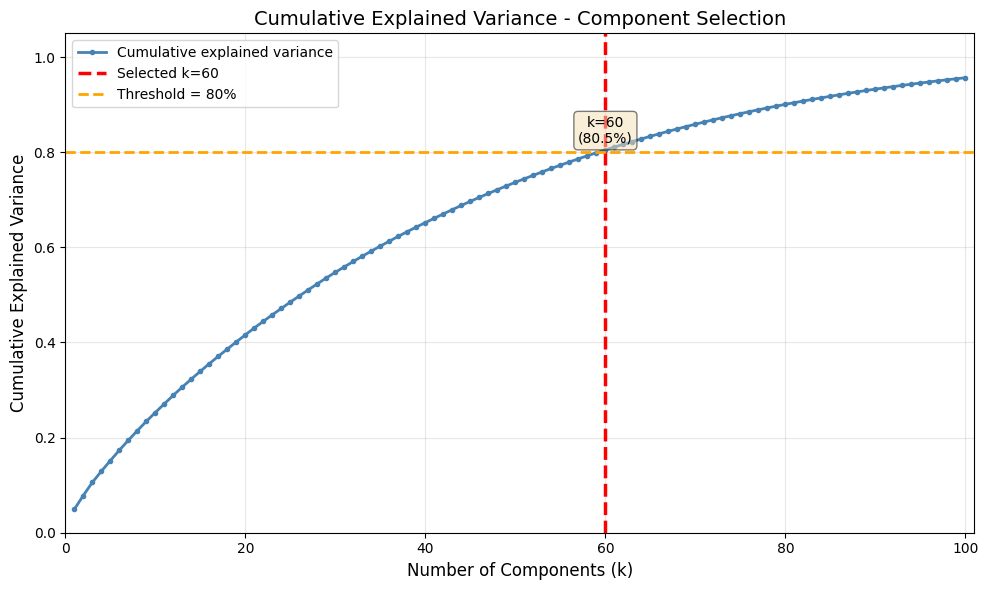


✓ Cumulative variance plot: k=60 selected at 80% threshold
  To adjust: change 'variance_threshold' variable (currently 0.8)


In [148]:
# Visualize cumulative explained variance and threshold
fig, ax = plt.subplots(1, 1, figsize=(10, 6))

# Plot cumulative explained variance
ax.plot(range(1, min(101, n_components+1)), cumulative_variance[:min(100, n_components)], 
        'o-', markersize=3, linewidth=2, label='Cumulative explained variance', color='steelblue')

# Mark selected k
ax.axvline(x=elbow_k, color='r', linestyle='--', linewidth=2.5, label=f'Selected k={elbow_k}')
ax.axhline(y=variance_threshold, color='orange', linestyle='--', linewidth=2, 
           label=f'Threshold = {variance_threshold*100:.0f}%')

# Add text annotation at intersection
ax.text(elbow_k, variance_threshold + 0.02, f'k={elbow_k}\n({cumulative_variance[elbow_k-1]*100:.1f}%)', 
        fontsize=10, ha='center', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

ax.set_xlabel('Number of Components (k)', fontsize=12)
ax.set_ylabel('Cumulative Explained Variance', fontsize=12)
ax.set_title('Cumulative Explained Variance - Component Selection', fontsize=14)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_xlim(0, min(101, n_components+1))
ax.set_ylim(0, 1.05)

plt.tight_layout()
plt.show()

print(f"\n✓ Cumulative variance plot: k={elbow_k} selected at {variance_threshold*100:.0f}% threshold")
print(f"  To adjust: change 'variance_threshold' variable (currently {variance_threshold})")


In [149]:
# Extract principal components (loadings) matrix with k_source components
# Shape: (k_source, num_columns) - dominant axes in neuron space
k_source = int(elbow_k)  # Rename for clarity - ensure int
n_neurons_source = firing_rate_normalized.shape[0]  # Number of neurons (n_samples)
n_features_source = firing_rate_normalized.shape[1]  # Number of time bins (n_features)
max_k_source = min(n_neurons_source, n_features_source)  # PCA constraint

# Cap k_source at max allowed by PCA
if k_source > max_k_source:
    print(f"Warning: k_source={k_source} exceeds max allowed ({max_k_source}). Capping to {max_k_source}.")
    k_source = max_k_source

print(f"Extracting principal components matrix with k_source={k_source} components...")
print(f"  Matrix shape: {firing_rate_normalized.shape} (n_neurons={n_neurons_source}, n_features={n_features_source})")
print(f"  Max k allowed: {max_k_source}")

# Refit PCA with k_source components
pca_source = PCA(n_components=k_source)
pca_source.fit(firing_rate_normalized)

# Extract principal components (loadings)
# These are the axes in neuron space: shape (k_source, n_features)
principal_components_source = pca_source.components_  # Shape: (k_source, num_columns)

# Compute scores: (n_units, k_source)
scores_source = pca_source.transform(firing_rate_normalized)  # Shape: (n_units, k_source)

print(f"\n=== Source Principal Components Matrix ===")
print(f"Principal components shape: {principal_components_source.shape} (k_source × num_columns)")
print(f"  k_source (components): {principal_components_source.shape[0]}")
print(f"  num_columns (features): {principal_components_source.shape[1]}")
print(f"\nScores shape: {scores_source.shape} (n_units × k_source)")
print(f"  n_units: {scores_source.shape[0]}")
print(f"  k_source: {scores_source.shape[1]}")

print(f"\nExplained variance:")
print(f"  Total (k_source components): {pca_source.explained_variance_ratio_.sum():.4f} ({pca_source.explained_variance_ratio_.sum()*100:.2f}%)")
print(f"  Per component:")
for i in range(k_source):
    print(f"    PC{i+1}: {pca_source.explained_variance_ratio_[i]:.4f} ({pca_source.explained_variance_ratio_[i]*100:.2f}%)")

print(f"\n✓ Source principal components matrix extracted: shape ({k_source}, {firing_rate_normalized.shape[1]})")


Extracting principal components matrix with k_source=60 components...
  Matrix shape: (159, 175) (n_neurons=159, n_features=175)
  Max k allowed: 159

=== Source Principal Components Matrix ===
Principal components shape: (60, 175) (k_source × num_columns)
  k_source (components): 60
  num_columns (features): 175

Scores shape: (159, 60) (n_units × k_source)
  n_units: 159
  k_source: 60

Explained variance:
  Total (k_source components): 0.8049 (80.49%)
  Per component:
    PC1: 0.0491 (4.91%)
    PC2: 0.0291 (2.91%)
    PC3: 0.0275 (2.75%)
    PC4: 0.0234 (2.34%)
    PC5: 0.0224 (2.24%)
    PC6: 0.0219 (2.19%)
    PC7: 0.0208 (2.08%)
    PC8: 0.0202 (2.02%)
    PC9: 0.0197 (1.97%)
    PC10: 0.0185 (1.85%)
    PC11: 0.0183 (1.83%)
    PC12: 0.0180 (1.80%)
    PC13: 0.0173 (1.73%)
    PC14: 0.0168 (1.68%)
    PC15: 0.0162 (1.62%)
    PC16: 0.0161 (1.61%)
    PC17: 0.0156 (1.56%)
    PC18: 0.0152 (1.52%)
    PC19: 0.0151 (1.51%)
    PC20: 0.0147 (1.47%)
    PC21: 0.0146 (1.46%)
    PC22

In [150]:
# Store source PCA results
print("=== Stored Source PCA Results ===")
print(f"k_source: {k_source}")
print(f"Principal components matrix: shape {principal_components_source.shape}")
print(f"Scores matrix: shape {scores_source.shape}")
print(f"Explained variance ratio (k_source components): {pca_source.explained_variance_ratio_}")
print(f"Cumulative variance (k_source components): {cumulative_variance[k_source-1]:.4f}")

# Store for later use
pca_model_source = pca_source
k_components_source = k_source
pc_matrix_source = principal_components_source  # Shape: (k_source, num_columns) - axes in neuron space
score_matrix_source = scores_source  # Shape: (n_units, k_source)

print(f"\n✓ Source PCA results stored: k_source={k_source}")
print(f"  Ready for target PCA (Section 7) with k_target = k_source / 2")


=== Stored Source PCA Results ===
k_source: 60
Principal components matrix: shape (60, 175)
Scores matrix: shape (159, 60)
Explained variance ratio (k_source components): [0.04914238 0.0290601  0.02746216 0.02343056 0.0223756  0.02192394
 0.02084514 0.02022589 0.01970915 0.01847725 0.01832739 0.0179837
 0.01728936 0.01683482 0.01624648 0.01607153 0.01556888 0.01519011
 0.01508478 0.01468675 0.01458448 0.01392166 0.01376909 0.01336403
 0.01335878 0.01292793 0.01286835 0.01261142 0.01246729 0.01176843
 0.01144015 0.01130655 0.01111722 0.01069901 0.01055109 0.01027282
 0.01023464 0.00992334 0.00958813 0.00929906 0.00918986 0.00909136
 0.00907621 0.00876965 0.00858353 0.00840456 0.00815131 0.00803251
 0.00782785 0.00768518 0.00739582 0.00735557 0.00723647 0.00719397
 0.00678875 0.00669638 0.00665508 0.00650563 0.00620927 0.00605603]
Cumulative variance (k_source components): 0.8049

✓ Source PCA results stored: k_source=60
  Ready for target PCA (Section 7) with k_target = k_source / 2


## 7. PCA Analysis (Target)

Run PCA on the brain region subset matrix (`firing_rate_normalized_target`) using k_target = k_source / 2.
This uses half the number of components from the source PCA.


In [151]:
# Determine k for target matrix: 1/2 of source matrix k
k_source = int(k_components_source)  # k from source PCA (Section 6) - ensure int
k_target = int(max(1, k_source // 2))  # Target k is 1/2 of source k (minimum 1) - ensure int

# Check PCA constraint: n_components <= min(n_samples, n_features)
n_neurons_target = firing_rate_normalized_target.shape[0]  # Number of neurons (n_samples)
n_features_target = firing_rate_normalized_target.shape[1]  # Number of time bins (n_features)
max_k_target = min(n_neurons_target, n_features_target)  # PCA constraint

# Cap k_target at max allowed by PCA
if k_target > max_k_target:
    print(f"Warning: k_target={k_target} exceeds max allowed ({max_k_target}). Capping to {max_k_target}.")
    k_target = max_k_target

print("=== Target Matrix PCA Setup ===")
print(f"Source matrix k (from Section 6): {k_source}")
print(f"Target matrix k: {k_target} (1/2 of source k, capped at max)")
print(f"Target matrix shape: {firing_rate_normalized_target.shape} (units × time bins)")
print(f"  n_neurons: {n_neurons_target}, n_features: {n_features_target}")
print(f"  Max k allowed: {max_k_target}")


=== Target Matrix PCA Setup ===
Source matrix k (from Section 6): 60
Target matrix k: 30 (1/2 of source k, capped at max)
Target matrix shape: (33, 175) (units × time bins)
  n_neurons: 33, n_features: 175
  Max k allowed: 33


In [152]:
# Run PCA on target matrix with k_target components
print(f"\nRunning PCA on target matrix with k_target={k_target} components...")

# Fit PCA with k_target components
pca_target = PCA(n_components=k_target)
pca_target.fit(firing_rate_normalized_target)

# Extract principal components (loadings)
# These are the axes in neuron space: shape (k_target, n_features)
principal_components_target = pca_target.components_  # Shape: (k_target, num_columns)

# Compute scores: (n_units, k_target)
scores_target = pca_target.transform(firing_rate_normalized_target)  # Shape: (n_units, k_target)

print(f"\n=== Target Matrix PCA Results ===")
print(f"Principal components shape: {principal_components_target.shape} (k_target × num_columns)")
print(f"  k_target (components): {principal_components_target.shape[0]}")
print(f"  num_columns (features): {principal_components_target.shape[1]}")
print(f"\nScores shape: {scores_target.shape} (n_units × k_target)")
print(f"  n_units: {scores_target.shape[0]}")
print(f"  k_target: {scores_target.shape[1]}")

print(f"\nExplained variance:")
print(f"  Total (k_target components): {pca_target.explained_variance_ratio_.sum():.4f} ({pca_target.explained_variance_ratio_.sum()*100:.2f}%)")
print(f"  Per component:")
for i in range(k_target):
    print(f"    PC{i+1}: {pca_target.explained_variance_ratio_[i]:.4f} ({pca_target.explained_variance_ratio_[i]*100:.2f}%)")

print(f"\n✓ Target matrix PCA completed: shape ({k_target}, {firing_rate_normalized_target.shape[1]})")



Running PCA on target matrix with k_target=30 components...

=== Target Matrix PCA Results ===
Principal components shape: (30, 175) (k_target × num_columns)
  k_target (components): 30
  num_columns (features): 175

Scores shape: (33, 30) (n_units × k_target)
  n_units: 33
  k_target: 30

Explained variance:
  Total (k_target components): 0.9821 (98.21%)
  Per component:
    PC1: 0.0737 (7.37%)
    PC2: 0.0600 (6.00%)
    PC3: 0.0573 (5.73%)
    PC4: 0.0549 (5.49%)
    PC5: 0.0523 (5.23%)
    PC6: 0.0486 (4.86%)
    PC7: 0.0470 (4.70%)
    PC8: 0.0452 (4.52%)
    PC9: 0.0444 (4.44%)
    PC10: 0.0393 (3.93%)
    PC11: 0.0372 (3.72%)
    PC12: 0.0346 (3.46%)
    PC13: 0.0332 (3.32%)
    PC14: 0.0323 (3.23%)
    PC15: 0.0309 (3.09%)
    PC16: 0.0292 (2.92%)
    PC17: 0.0277 (2.77%)
    PC18: 0.0258 (2.58%)
    PC19: 0.0251 (2.51%)
    PC20: 0.0223 (2.23%)
    PC21: 0.0219 (2.19%)
    PC22: 0.0192 (1.92%)
    PC23: 0.0188 (1.88%)
    PC24: 0.0176 (1.76%)
    PC25: 0.0164 (1.64%)
    PC26

In [153]:
# Store target PCA results
print("=== Stored Target PCA Results ===")
print(f"k_target: {k_target}")
print(f"Principal components matrix: shape {principal_components_target.shape}")
print(f"Scores matrix: shape {scores_target.shape}")
print(f"Explained variance ratio: {pca_target.explained_variance_ratio_}")

# Store for later use
pca_model_target = pca_target
k_components_target = k_target
pc_matrix_target = principal_components_target  # Shape: (k_target, num_columns) - axes in neuron space
score_matrix_target = scores_target  # Shape: (n_units, k_target)

print(f"\n✓ Target PCA results stored")
print(f"  Comparison: Source k={k_source}, Target k={k_target} (target = source / 2)")


=== Stored Target PCA Results ===
k_target: 30
Principal components matrix: shape (30, 175)
Scores matrix: shape (33, 30)
Explained variance ratio: [0.07369157 0.05998389 0.05727511 0.05488578 0.05230524 0.04864487
 0.04700111 0.04515123 0.04436018 0.03933948 0.03724029 0.03457982
 0.03316028 0.03225891 0.03091296 0.02918912 0.02766587 0.0257792
 0.02508172 0.02228646 0.02191062 0.01920573 0.01877539 0.01764287
 0.0164389  0.01611639 0.01370161 0.01338089 0.01261154 0.01156099]

✓ Target PCA results stored
  Comparison: Source k=60, Target k=30 (target = source / 2)


## 8. Ridge Regression for Null Space Estimation

Estimate the mapping matrix W from fit (movement/probe) to project (prep/maintenance) PCA components using ridge regression, trained only on fit epoch columns.


In [154]:
# Step 1: Verify Fit/Project Index Vectors
# Use existing idx_fit and idx_project from Section 4

print("=== Fit/Project Index Vectors ===")
print(f"Total columns in combined matrix: {firing_rate_combined.shape[1]}")
print(f"  Fit epoch (idx_fit): {idx_fit.sum()} columns")
print(f"  Project epoch (idx_project): {idx_project.sum()} columns")
print(f"\nVerification:")
print(f"  idx_project + idx_fit should equal all True: {(idx_project | idx_fit).all()}")
print(f"  No overlap: {(idx_project & idx_fit).sum() == 0}")
print(f"\n✓ Index vectors ready:")
print(f"  idx_fit: fit epoch columns (movement/probe)")
print(f"  idx_project: project epoch columns (prep/maintenance)")


=== Fit/Project Index Vectors ===
Total columns in combined matrix: 175
  Fit epoch (idx_fit): 50 columns
  Project epoch (idx_project): 125 columns

Verification:
  idx_project + idx_fit should equal all True: True
  No overlap: True

✓ Index vectors ready:
  idx_fit: fit epoch columns (movement/probe)
  idx_project: project epoch columns (prep/maintenance)


In [155]:
# Step 2: Extract Training Matrices
# Training uses only fit columns (movement/probe epoch)

# Extract SOURCE PCA components (activity from area that sends output)
# N_train should have k_source rows
N_train = pc_matrix_source[:, idx_fit]   # shape: (k_source, num_fit_cols)

# Extract TARGET PCA components (activity or behavior that receives)
# M_train should have k_target rows
M_train = pc_matrix_target[:, idx_fit]   # shape: (k_target, num_fit_cols)

print("=== Training Matrices ===")
print(f"N_train (SOURCE PCA, fit columns): shape {N_train.shape}")
print(f"  k_source: {N_train.shape[0]} (should be {k_components_source})")
print(f"  num_fit_cols: {N_train.shape[1]}")
print(f"\nM_train (TARGET PCA, fit columns): shape {M_train.shape}")
print(f"  k_target: {M_train.shape[0]} (should be {k_components_target})")
print(f"  num_fit_cols: {M_train.shape[1]}")

print(f"\n✓ Training matrices extracted (using fit columns only)")


=== Training Matrices ===
N_train (SOURCE PCA, fit columns): shape (60, 50)
  k_source: 60 (should be 60)
  num_fit_cols: 50

M_train (TARGET PCA, fit columns): shape (30, 50)
  k_target: 30 (should be 30)
  num_fit_cols: 50

✓ Training matrices extracted (using fit columns only)


In [156]:
# Step 3: Implement Ridge Regression
# Ridge regression: M ≈ W * N
# W = (M_train @ N_train.T) @ inv(N_train @ N_train.T + lam * I_k_source)
# Shape: (k_target, k_source)

# Set ridge regularization parameter
lam = 0.1  # Can be adjusted/tuned

print("=== Ridge Regression Setup ===")
print(f"Ridge parameter λ: {lam}")
print(f"N_train shape: {N_train.shape} (k_source × num_fit_cols)")
print(f"M_train shape: {M_train.shape} (k_target × num_fit_cols)")

# Compute components of ridge regression formula
# N_train @ N_train.T: shape (k_source, k_source)
NNT = N_train @ N_train.T

# Identity matrix scaled by lambda: λ * I_k_source
I_k = lam * np.eye(N_train.shape[0])  # N_train.shape[0] = k_source

# Regularized covariance: N_train @ N_train.T + λ * I_k_source
regularized_cov = NNT + I_k

# Compute inverse: inv(N_train @ N_train.T + λ * I_k_source)
regularized_cov_inv = np.linalg.inv(regularized_cov)

# M_train @ N_train.T: shape (k_target, k_source)
MNT = M_train @ N_train.T

# Final W: shape (k_target, k_source)
W = (MNT @ regularized_cov_inv)

print(f"\n=== Ridge Regression Results ===")
print(f"W shape: {W.shape} (k_target × k_source)")
print(f"  k_target: {W.shape[0]}")
print(f"  k_source: {W.shape[1]}")
print(f"\nW statistics:")
print(f"  Mean: {W.mean():.6f}")
print(f"  Std: {W.std():.6f}")
print(f"  Min: {W.min():.6f}")
print(f"  Max: {W.max():.6f}")
print(f"\n✓ Ridge regression completed")


=== Ridge Regression Setup ===
Ridge parameter λ: 0.1
N_train shape: (60, 50) (k_source × num_fit_cols)
M_train shape: (30, 50) (k_target × num_fit_cols)

=== Ridge Regression Results ===
W shape: (30, 60) (k_target × k_source)
  k_target: 30
  k_source: 60

W statistics:
  Mean: -0.002872
  Std: 0.082154
  Min: -0.280673
  Max: 0.355400

✓ Ridge regression completed


In [157]:
# Step 4: Store and Verify Results

# Store W matrix and ridge parameter
W_matrix = W
lambda_ridge_value = lam

print("=== Stored Ridge Regression Results ===")
print(f"W_matrix shape: {W_matrix.shape} (k_target × k_source)")
print(f"  k_target: {W_matrix.shape[0]}")
print(f"  k_source: {W_matrix.shape[1]}")
print(f"\nLambda (ridge parameter): {lambda_ridge_value}")
print(f"\nW_matrix statistics:")
print(f"  Mean: {W_matrix.mean():.6f}")
print(f"  Std: {W_matrix.std():.6f}")
print(f"  Min: {W_matrix.min():.6f}")
print(f"  Max: {W_matrix.max():.6f}")

# Verify dimensions
assert W_matrix.shape == (k_components_target, k_components_source), \
    f"W_matrix shape mismatch: expected ({k_components_target}, {k_components_source}), got {W_matrix.shape}"

print(f"\n✓ W matrix stored and verified")
print(f"  Ready for null space projection")


=== Stored Ridge Regression Results ===
W_matrix shape: (30, 60) (k_target × k_source)
  k_target: 30
  k_source: 60

Lambda (ridge parameter): 0.1

W_matrix statistics:
  Mean: -0.002872
  Std: 0.082154
  Min: -0.280673
  Max: 0.355400

✓ W matrix stored and verified
  Ready for null space projection


## 9. SVD Decomposition for Potent/Null Spaces

Decompose W using SVD to identify potent and null spaces in source space. The potent basis spans the dimensions that map from target to source, while the null space is the orthogonal complement in R^k_source.


In [158]:
# Step 1: Perform SVD on W
# W = U @ diag(S) @ Vt

print("=== SVD Decomposition of W ===")
print(f"W shape: {W.shape} (k_target × k_source)")

# Perform SVD
U, S, Vt = np.linalg.svd(W, full_matrices=False)

print(f"\nSVD Results:")
print(f"  U shape: {U.shape} (k_target × rank)")
print(f"  S length: {len(S)}")
print(f"  Vt shape: {Vt.shape} (rank × k_source)")

# Identify non-zero singular values (with tolerance for numerical precision)
tolerance = 1e-8
rank = (S > tolerance).sum()

print(f"\nSingular values:")
print(f"  Total: {len(S)}")
print(f"  Non-zero (rank): {rank} (tolerance: {tolerance})")
print(f"  Range: [{S.min():.6e}, {S.max():.6e}]")
print(f"\nNon-zero singular values:")
for i in range(min(rank, 10)):
    print(f"  σ{i+1}: {S[i]:.6e}")
if rank > 10:
    print(f"  ... ({rank - 10} more)")

print(f"\n✓ SVD decomposition completed")
print(f"  Rank: {rank} (≤ k_source = {N_train.shape[0]})")


=== SVD Decomposition of W ===
W shape: (30, 60) (k_target × k_source)

SVD Results:
  U shape: (30, 30) (k_target × rank)
  S length: 30
  Vt shape: (30, 60) (rank × k_source)

Singular values:
  Total: 30
  Non-zero (rank): 30 (tolerance: 1e-08)
  Range: [2.282589e-01, 9.890476e-01]

Non-zero singular values:
  σ1: 9.890476e-01
  σ2: 9.597729e-01
  σ3: 9.187479e-01
  σ4: 8.857173e-01
  σ5: 8.512205e-01
  σ6: 8.048207e-01
  σ7: 7.987958e-01
  σ8: 7.632229e-01
  σ9: 7.540259e-01
  σ10: 7.447056e-01
  ... (20 more)

✓ SVD decomposition completed
  Rank: 30 (≤ k_source = 60)


In [159]:
# Step 2: Extract Potent Basis and Compute Projection Matrices
# Potent basis in source space = rows of V^T for non-zero singular values

# Extract potent basis: V_pot = Vt[:rank, :] in source space
V_pot = Vt[:rank, :]  # Shape: (rank, k_source) in source space

# Compute null dimension
null_dim = N_train.shape[0] - rank  # N_train.shape[0] = k_source

print("=== Potent Basis ===")
print(f"V_pot shape: {V_pot.shape} (rank × k_source)")
print(f"  rank: {rank}")
print(f"  k_source: {V_pot.shape[1]}")
print(f"\nNull dimension:")
print(f"  null_dim = N_train.shape[0] - rank = {N_train.shape[0]} - {rank} = {null_dim}")
print(f"  Expected: null_dim ≥ 0")

# Compute projection matrices
# P_pot: projection onto potent space (k_source × k_source)
P_pot = V_pot.T @ V_pot  # Shape: (k_source, k_source)

# P_null: projection onto null space (k_source × k_source)
P_null = np.eye(N_train.shape[0]) - P_pot  # Shape: (k_source, k_source)

print(f"\n=== Projection Matrices ===")
print(f"P_pot shape: {P_pot.shape} (k_source × k_source)")
print(f"P_null shape: {P_null.shape} (k_source × k_source)")

print(f"\n✓ Potent basis and projection matrices computed")
print(f"  Rank: {rank} (≤ k_source = {N_train.shape[0]})")
print(f"  Null dimension: {null_dim}")


=== Potent Basis ===
V_pot shape: (30, 60) (rank × k_source)
  rank: 30
  k_source: 60

Null dimension:
  null_dim = N_train.shape[0] - rank = 60 - 30 = 30
  Expected: null_dim ≥ 0

=== Projection Matrices ===
P_pot shape: (60, 60) (k_source × k_source)
P_null shape: (60, 60) (k_source × k_source)

✓ Potent basis and projection matrices computed
  Rank: 30 (≤ k_source = 60)
  Null dimension: 30


In [160]:
# Step 3: Verify Projection Matrices

print("=== Verification ===")

# Verify P_pot properties
print(f"P_pot properties:")
print(f"  Shape: {P_pot.shape}")
print(f"  Trace (should equal rank): {np.trace(P_pot):.6f} (rank = {rank})")
print(f"  Symmetric check: {np.allclose(P_pot, P_pot.T)}")

# Verify P_null properties
print(f"\nP_null properties:")
print(f"  Shape: {P_null.shape}")
print(f"  Trace (should equal null_dim): {np.trace(P_null):.6f} (null_dim = {null_dim})")
print(f"  Symmetric check: {np.allclose(P_null, P_null.T)}")

# Verify orthogonality: P_pot @ P_null should be approximately zero
orthogonality_check = P_pot @ P_null
max_orthogonality_error = np.abs(orthogonality_check).max()
print(f"\nOrthogonality check (P_pot @ P_null):")
print(f"  Max absolute value: {max_orthogonality_error:.6e}")
print(f"  Should be ≈ 0: {'✓' if max_orthogonality_error < 1e-10 else '✗'}")

# Verify completeness: P_pot + P_null should equal identity
completeness_check = P_pot + P_null
identity_error = np.abs(completeness_check - np.eye(N_train.shape[0])).max()
print(f"\nCompleteness check (P_pot + P_null = I):")
print(f"  Max absolute error: {identity_error:.6e}")
print(f"  Should be ≈ 0: {'✓' if identity_error < 1e-10 else '✗'}")

print(f"\n✓ Projection matrices verified")


=== Verification ===
P_pot properties:
  Shape: (60, 60)
  Trace (should equal rank): 30.000000 (rank = 30)
  Symmetric check: True

P_null properties:
  Shape: (60, 60)
  Trace (should equal null_dim): 30.000000 (null_dim = 30)
  Symmetric check: True

Orthogonality check (P_pot @ P_null):
  Max absolute value: 4.740953e-16
  Should be ≈ 0: ✓

Completeness check (P_pot + P_null = I):
  Max absolute error: 0.000000e+00
  Should be ≈ 0: ✓

✓ Projection matrices verified


In [161]:
# Step 4: Store Results

# Store SVD components and projection matrices
U_svd = U
S_svd = S
Vt_svd = Vt
V_pot_stored = V_pot
P_pot_stored = P_pot
P_null_stored = P_null
rank_potent = rank
dim_null_stored = null_dim

print("=== Stored SVD Results ===")
print(f"U_svd shape: {U_svd.shape} (k_target × rank)")
print(f"S_svd length: {len(S_svd)}")
print(f"Vt_svd shape: {Vt_svd.shape} (rank × k_source)")
print(f"\nV_pot shape: {V_pot_stored.shape} (rank × k_source)")
print(f"P_pot shape: {P_pot_stored.shape} (k_source × k_source)")
print(f"P_null shape: {P_null_stored.shape} (k_source × k_source)")
print(f"\nrank_potent: {rank_potent}")
print(f"dim_null: {dim_null_stored}")

# Verify dimensions
dim_check = rank_potent + dim_null_stored == N_train.shape[0]
print(f"\nDimension check:")
print(f"  rank_potent + dim_null = {rank_potent} + {dim_null_stored} = {rank_potent + dim_null_stored}")
print(f"  k_source = {N_train.shape[0]}")
print(f"  Match: {'✓' if dim_check else '✗'}")

# Verify reconstruction: W ≈ U @ diag(S) @ Vt
W_reconstructed = U @ np.diag(S) @ Vt
reconstruction_error = np.abs(W - W_reconstructed).max()
print(f"\nReconstruction check (W ≈ U @ diag(S) @ Vt):")
print(f"  Max absolute error: {reconstruction_error:.6e}")
print(f"  Should be ≈ 0: {'✓' if reconstruction_error < 1e-10 else '✗'}")

print(f"\n✓ SVD decomposition completed and verified")
print(f"  Potent space: rank {rank_potent} (in R^k_source = R^{N_train.shape[0]})")
print(f"  Null space: dimension {dim_null_stored} (in R^k_source = R^{N_train.shape[0]})")


=== Stored SVD Results ===
U_svd shape: (30, 30) (k_target × rank)
S_svd length: 30
Vt_svd shape: (30, 60) (rank × k_source)

V_pot shape: (30, 60) (rank × k_source)
P_pot shape: (60, 60) (k_source × k_source)
P_null shape: (60, 60) (k_source × k_source)

rank_potent: 30
dim_null: 30

Dimension check:
  rank_potent + dim_null = 30 + 30 = 60
  k_source = 60
  Match: ✓

Reconstruction check (W ≈ U @ diag(S) @ Vt):
  Max absolute error: 7.771561e-16
  Should be ≈ 0: ✓

✓ SVD decomposition completed and verified
  Potent space: rank 30 (in R^k_source = R^60)
  Null space: dimension 30 (in R^k_source = R^60)


## 10. Projection to All Columns

Project source PCA components for ALL columns (encoding/delay/probe/press) onto the potent and null spaces using P_pot and P_null. This decomposes the entire source activity into components that map to target (potent) and components that do not (null).


In [162]:
# Step 1: Extract Source PCA Components for All Columns
# N_all: (k_source, T_all) source PCs for any columns (encoding/delay/probe/press)

# Extract source PCA components for all columns
N_all = pc_matrix_source  # Shape: (k_source, T_all) where T_all = total number of time bins
T_all = N_all.shape[1]

print("=== Source PCA Components for All Columns ===")
print(f"N_all shape: {N_all.shape} (k_source × T_all)")
print(f"  k_source: {N_all.shape[0]}")
print(f"  T_all (total columns): {T_all}")
print(f"\nEpoch breakdown:")
print(f"  Projection epoch (idx_project): {idx_project.sum()} columns")
print(f"  Fit epoch (idx_fit): {idx_fit.sum()} columns")
print(f"  Total: {idx_project.sum() + idx_fit.sum()} columns")

print(f"\n✓ N_all extracted: source PCA components for all time bins")


=== Source PCA Components for All Columns ===
N_all shape: (60, 175) (k_source × T_all)
  k_source: 60
  T_all (total columns): 175

Epoch breakdown:
  Projection epoch (idx_project): 125 columns
  Fit epoch (idx_fit): 50 columns
  Total: 175 columns

✓ N_all extracted: source PCA components for all time bins


In [163]:
# Step 2: Project onto Potent Space
# N_pot = P_pot @ N_all

print("=== Projection onto Potent Space ===")
print(f"P_pot shape: {P_pot.shape} (k_source × k_source)")
print(f"N_all shape: {N_all.shape} (k_source × T_all)")

# Project N_all onto potent space
N_pot = P_pot @ N_all  # Shape: (k_source, T_all)

print(f"\nN_pot shape: {N_pot.shape} (k_source × T_all)")
print(f"  k_source: {N_pot.shape[0]}")
print(f"  T_all: {N_pot.shape[1]}")

print(f"\nN_pot statistics:")
print(f"  Mean: {N_pot.mean():.6f}")
print(f"  Std: {N_pot.std():.6f}")
print(f"  Min: {N_pot.min():.6f}")
print(f"  Max: {N_pot.max():.6f}")

print(f"\n✓ Potent projection completed")
print(f"  N_pot represents component that maps to target (movement/probe)")


=== Projection onto Potent Space ===
P_pot shape: (60, 60) (k_source × k_source)
N_all shape: (60, 175) (k_source × T_all)

N_pot shape: (60, 175) (k_source × T_all)
  k_source: 60
  T_all: 175

N_pot statistics:
  Mean: 0.000000
  Std: 0.053452
  Min: -0.194501
  Max: 0.244695

✓ Potent projection completed
  N_pot represents component that maps to target (movement/probe)


In [164]:
# Step 3: Project onto Null Space
# N_null = P_null @ N_all

print("=== Projection onto Null Space ===")
print(f"P_null shape: {P_null.shape} (k_source × k_source)")
print(f"N_all shape: {N_all.shape} (k_source × T_all)")

# Project N_all onto null space
N_null = P_null @ N_all  # Shape: (k_source, T_all)

print(f"\nN_null shape: {N_null.shape} (k_source × T_all)")
print(f"  k_source: {N_null.shape[0]}")
print(f"  T_all: {N_null.shape[1]}")

print(f"\nN_null statistics:")
print(f"  Mean: {N_null.mean():.6f}")
print(f"  Std: {N_null.std():.6f}")
print(f"  Min: {N_null.min():.6f}")
print(f"  Max: {N_null.max():.6f}")

print(f"\n✓ Null projection completed")
print(f"  N_null represents component that does NOT map to target")


=== Projection onto Null Space ===
P_null shape: (60, 60) (k_source × k_source)
N_all shape: (60, 175) (k_source × T_all)

N_null shape: (60, 175) (k_source × T_all)
  k_source: 60
  T_all: 175

N_null statistics:
  Mean: -0.000000
  Std: 0.053452
  Min: -0.202572
  Max: 0.233818

✓ Null projection completed
  N_null represents component that does NOT map to target


In [165]:
# Step 4: Verify Decomposition

print("=== Verification ===")

# Verify that potent + null = original
N_all_reconstructed = N_pot + N_null
reconstruction_error = np.abs(N_all - N_all_reconstructed).max()
print(f"Reconstruction check (N_pot + N_null = N_all):")
print(f"  Max absolute error: {reconstruction_error:.6e}")
print(f"  Should be ≈ 0: {'✓' if reconstruction_error < 1e-10 else '✗'}")

# Verify orthogonality: N_pot.T @ N_null should be approximately zero
orthogonality_matrix = N_pot.T @ N_null  # Shape: (T_all, T_all)
max_orthogonality_error = np.abs(orthogonality_matrix).max()
print(f"\nOrthogonality check (N_pot.T @ N_null ≈ 0):")
print(f"  Max absolute value: {max_orthogonality_error:.6e}")
print(f"  Should be ≈ 0: {'✓' if max_orthogonality_error < 1e-10 else '✗'}")

# Compute variance explained by each component
variance_all = np.var(N_all, axis=0).sum()  # Total variance
variance_pot = np.var(N_pot, axis=0).sum()  # Variance in potent space
variance_null = np.var(N_null, axis=0).sum()  # Variance in null space
variance_ratio = variance_pot / variance_null if variance_null > 0 else np.inf

print(f"\nVariance explained:")
print(f"  Total variance (N_all): {variance_all:.6f}")
print(f"  Potent variance (N_pot): {variance_pot:.6f} ({variance_pot/variance_all*100:.2f}%)")
print(f"  Null variance (N_null): {variance_null:.6f} ({variance_null/variance_all*100:.2f}%)")
print(f"  Potent/Null ratio: {variance_ratio:.4f}")

# Verify variance decomposition (should be approximately equal due to orthogonality)
variance_sum = variance_pot + variance_null
variance_decomp_error = np.abs(variance_all - variance_sum) / variance_all
print(f"\nVariance decomposition check:")
print(f"  variance_pot + variance_null = {variance_sum:.6f}")
print(f"  Relative error: {variance_decomp_error:.6e}")
print(f"  Should be ≈ 0: {'✓' if variance_decomp_error < 1e-6 else '✗'}")

print(f"\n✓ Decomposition verified")


=== Verification ===
Reconstruction check (N_pot + N_null = N_all):
  Max absolute error: 1.387779e-16
  Should be ≈ 0: ✓

Orthogonality check (N_pot.T @ N_null ≈ 0):
  Max absolute value: 2.588284e-16
  Should be ≈ 0: ✓

Variance explained:
  Total variance (N_all): 0.983333
  Potent variance (N_pot): 0.491427 (49.98%)
  Null variance (N_null): 0.491907 (50.02%)
  Potent/Null ratio: 0.9990

Variance decomposition check:
  variance_pot + variance_null = 0.983333
  Relative error: 1.129040e-16
  Should be ≈ 0: ✓

✓ Decomposition verified


In [166]:
# Step 5: Store Results

# Store all projection results
N_all_stored = N_all
N_pot_stored = N_pot
N_null_stored = N_null

# Store variance statistics
projection_stats = {
    'variance_all': variance_all,
    'variance_pot': variance_pot,
    'variance_null': variance_null,
    'variance_ratio': variance_ratio,
    'reconstruction_error': reconstruction_error,
    'orthogonality_error': max_orthogonality_error
}

print("=== Stored Projection Results ===")
print(f"N_all_stored shape: {N_all_stored.shape} (k_source × T_all)")
print(f"N_pot_stored shape: {N_pot_stored.shape} (k_source × T_all)")
print(f"N_null_stored shape: {N_null_stored.shape} (k_source × T_all)")
print(f"\nProjection statistics:")
print(f"  Variance ratio (pot/null): {projection_stats['variance_ratio']:.4f}")
print(f"  Reconstruction error: {projection_stats['reconstruction_error']:.6e}")
print(f"  Orthogonality error: {projection_stats['orthogonality_error']:.6e}")

print(f"\n✓ All projection results stored")
print(f"  Ready for further analysis and visualization")


=== Stored Projection Results ===
N_all_stored shape: (60, 175) (k_source × T_all)
N_pot_stored shape: (60, 175) (k_source × T_all)
N_null_stored shape: (60, 175) (k_source × T_all)

Projection statistics:
  Variance ratio (pot/null): 0.9990
  Reconstruction error: 1.387779e-16
  Orthogonality error: 2.588284e-16

✓ All projection results stored
  Ready for further analysis and visualization


## 11. Per-Epoch Null vs Potent Occupancy (Tuning Ratio)

Compute tuning ratio (TR) for each epoch by measuring dimension-normalized energy in potent vs null spaces. Expected: TR > 1 in encoding/delay, TR decreases near response. Include bootstrap confidence intervals.


In [167]:
# Step 1: Create Epoch Column Masks
# Currently we have idx_project (maintenance) and idx_fit (probe)

print("=== Epoch Column Masks ===")
print(f"Total columns: {N_all.shape[1]}")

print(f"\nidx_project (maintenance/delay):")
print(f"  Number of columns: {idx_project.sum()}")
print(f"  Column indices: {np.where(idx_project)[0][:10]}..." if idx_project.sum() > 10 else f"  Column indices: {np.where(idx_project)[0]}")

print(f"\nidx_fit (probe/movement):")
print(f"  Number of columns: {idx_fit.sum()}")
print(f"  Column indices: {np.where(idx_fit)[0][:10]}..." if idx_fit.sum() > 10 else f"  Column indices: {np.where(idx_fit)[0]}")

# Store epoch masks
epoch_masks = {
    'delay': idx_project,  # Maintenance/delay period
    'move': idx_fit        # Probe/movement period
}

print(f"\n✓ Epoch masks created:")
print(f"  delay: {epoch_masks['delay'].sum()} columns")
print(f"  move: {epoch_masks['move'].sum()} columns")


=== Epoch Column Masks ===
Total columns: 175

idx_project (maintenance/delay):
  Number of columns: 125
  Column indices: [0 1 2 3 4 5 6 7 8 9]...

idx_fit (probe/movement):
  Number of columns: 50
  Column indices: [125 126 127 128 129 130 131 132 133 134]...

✓ Epoch masks created:
  delay: 125 columns
  move: 50 columns


In [168]:
# Step 2: Compute Energy Functions
# E_pot(E) = (1/r) * <||P_pot @ N_E||_F^2>
# E_null(E) = (1/(k-r)) * <||P_null @ N_E||_F^2>

# Get dimensions
r = rank_potent  # Rank of potent space
k = N_all.shape[0]  # k_source

print("=== Energy Computation Setup ===")
print(f"r (rank_potent): {r}")
print(f"k (k_source): {k}")
print(f"k - r (null_dim): {k - r}")

def compute_energy(epoch_mask):
    """
    Compute dimension-normalized energy in potent and null spaces for an epoch.
    
    Args:
        epoch_mask: Boolean array indicating columns belonging to epoch
        
    Returns:
        E_pot: Dimension-normalized energy in potent space
        E_null: Dimension-normalized energy in null space
    """
    # Extract source PCs for this epoch
    N_E = N_all[:, epoch_mask]  # Shape: (k_source, num_epoch_cols)
    
    if N_E.shape[1] == 0:
        return np.nan, np.nan
    
    # Project onto potent space: P_pot @ N_E
    N_E_pot = P_pot @ N_E  # Shape: (k_source, num_epoch_cols)
    
    # Project onto null space: P_null @ N_E
    N_E_null = P_null @ N_E  # Shape: (k_source, num_epoch_cols)
    
    # Compute squared Frobenius norm for each column, then take mean
    # ||A||_F^2 = sum of squares of all elements
    # For each column: ||N_E_pot[:, i]||^2
    frobenius_norm_sq_pot = np.sum(N_E_pot ** 2, axis=0)  # Shape: (num_epoch_cols,)
    frobenius_norm_sq_null = np.sum(N_E_null ** 2, axis=0)  # Shape: (num_epoch_cols,)
    
    # Mean across columns: <||P_pot @ N_E||_F^2>
    mean_frob_sq_pot = np.mean(frobenius_norm_sq_pot)
    mean_frob_sq_null = np.mean(frobenius_norm_sq_null)
    
    # Dimension-normalized energy
    E_pot = (1.0 / r) * mean_frob_sq_pot if r > 0 else np.nan
    E_null = (1.0 / (k - r)) * mean_frob_sq_null if (k - r) > 0 else np.nan
    
    return E_pot, E_null

print(f"\n✓ Energy computation function defined")
print(f"  E_pot(E) = (1/r) * mean(||P_pot @ N_E||_F^2)")
print(f"  E_null(E) = (1/(k-r)) * mean(||P_null @ N_E||_F^2)")


=== Energy Computation Setup ===
r (rank_potent): 30
k (k_source): 60
k - r (null_dim): 30

✓ Energy computation function defined
  E_pot(E) = (1/r) * mean(||P_pot @ N_E||_F^2)
  E_null(E) = (1/(k-r)) * mean(||P_null @ N_E||_F^2)


In [169]:
# Step 3: Compute Tuning Ratio for Each Epoch

print("=== Tuning Ratio Computation ===")

epoch_results = {}

# Compute energy and TR for each epoch
for epoch_name, epoch_mask in epoch_masks.items():
    E_pot_val, E_null_val = compute_energy(epoch_mask)
    
    # Compute tuning ratio: TR = E_null / E_pot
    if E_pot_val > 0 and not np.isnan(E_pot_val) and not np.isnan(E_null_val):
        TR = E_null_val / E_pot_val
    else:
        TR = np.nan
    
    epoch_results[epoch_name] = {
        'E_pot': E_pot_val,
        'E_null': E_null_val,
        'TR': TR,
        'n_columns': epoch_mask.sum()
    }
    
    print(f"\n{epoch_name.upper()} epoch:")
    print(f"  Columns: {epoch_mask.sum()}")
    print(f"  E_pot: {E_pot_val:.6f}")
    print(f"  E_null: {E_null_val:.6f}")
    print(f"  TR = E_null/E_pot: {TR:.4f}")

# Create summary DataFrame
import pandas as pd
results_df = pd.DataFrame(epoch_results).T
results_df.index.name = 'epoch'
results_df = results_df.reset_index()

print(f"\n=== Summary Table ===")
print(results_df.to_string(index=False))

print(f"\n✓ Tuning ratios computed")
print(f"  Expected: TR > 1 in delay (more null space activity)")
print(f"  Expected: TR decreases in move (more potent space activity)")


=== Tuning Ratio Computation ===

DELAY epoch:
  Columns: 125
  E_pot: 0.004916
  E_null: 0.006632
  TR = E_null/E_pot: 1.3491

MOVE epoch:
  Columns: 50
  E_pot: 0.007710
  E_null: 0.003419
  TR = E_null/E_pot: 0.4435

=== Summary Table ===
epoch    E_pot   E_null       TR  n_columns
delay 0.004916 0.006632 1.349099      125.0
 move 0.007710 0.003419 0.443470       50.0

✓ Tuning ratios computed
  Expected: TR > 1 in delay (more null space activity)
  Expected: TR decreases in move (more potent space activity)


In [170]:
# Step 4: Bootstrap Confidence Intervals

print("=== Bootstrap Confidence Intervals ===")

n_bootstrap = 1000  # Number of bootstrap iterations
bootstrap_results = {}

for epoch_name, epoch_mask in epoch_masks.items():
    # Get column indices for this epoch
    epoch_col_indices = np.where(epoch_mask)[0]
    n_cols = len(epoch_col_indices)
    
    if n_cols == 0:
        bootstrap_results[epoch_name] = {
            'TR_samples': [],
            'TR_mean': np.nan,
            'TR_ci_lower': np.nan,
            'TR_ci_upper': np.nan
        }
        continue
    
    # Bootstrap: resample columns with replacement
    np.random.seed(42)  # For reproducibility
    TR_samples = []
    
    for i in range(n_bootstrap):
        # Resample column indices with replacement
        bootstrap_indices = np.random.choice(epoch_col_indices, size=n_cols, replace=True)
        
        # Create bootstrap mask
        bootstrap_mask = np.zeros(N_all.shape[1], dtype=bool)
        bootstrap_mask[bootstrap_indices] = True
        
        # Compute energy and TR for bootstrap sample
        E_pot_boot, E_null_boot = compute_energy(bootstrap_mask)
        
        if E_pot_boot > 0 and not np.isnan(E_pot_boot) and not np.isnan(E_null_boot):
            TR_boot = E_null_boot / E_pot_boot
            TR_samples.append(TR_boot)
    
    # Compute statistics
    TR_samples = np.array(TR_samples)
    TR_mean = np.mean(TR_samples)
    TR_ci_lower = np.percentile(TR_samples, 2.5)  # 95% CI lower bound
    TR_ci_upper = np.percentile(TR_samples, 97.5)  # 95% CI upper bound
    
    bootstrap_results[epoch_name] = {
        'TR_samples': TR_samples,
        'TR_mean': TR_mean,
        'TR_ci_lower': TR_ci_lower,
        'TR_ci_upper': TR_ci_upper
    }
    
    print(f"\n{epoch_name.upper()} epoch bootstrap:")
    print(f"  Mean TR: {TR_mean:.4f}")
    print(f"  95% CI: [{TR_ci_lower:.4f}, {TR_ci_upper:.4f}]")
    print(f"  Original TR: {epoch_results[epoch_name]['TR']:.4f}")

print(f"\n✓ Bootstrap confidence intervals computed ({n_bootstrap} iterations)")


=== Bootstrap Confidence Intervals ===

DELAY epoch bootstrap:
  Mean TR: 1.3497
  95% CI: [1.2883, 1.4122]
  Original TR: 1.3491

MOVE epoch bootstrap:
  Mean TR: 0.4446
  95% CI: [0.4002, 0.4904]
  Original TR: 0.4435

✓ Bootstrap confidence intervals computed (1000 iterations)


=== Visualization ===


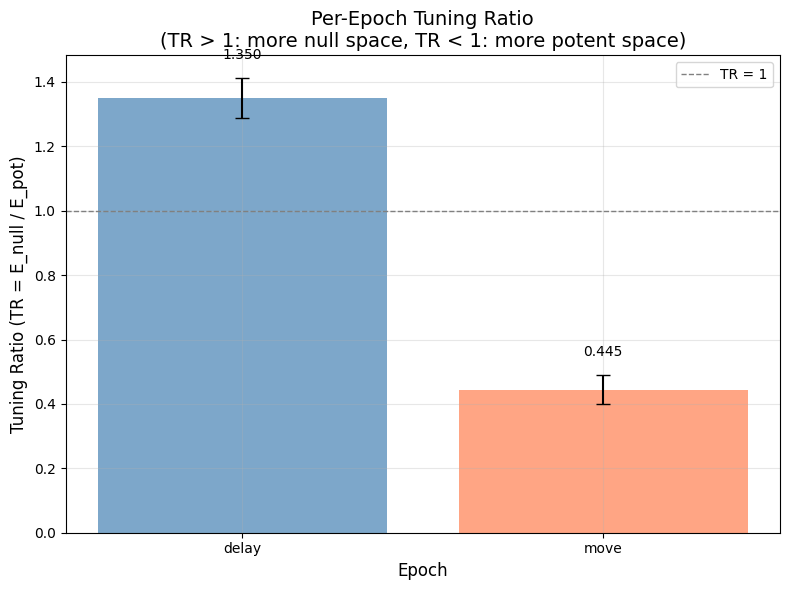


✓ Visualization created
  Expected pattern: TR > 1 in delay, TR decreases in move


In [171]:
# Step 5: Visualize Results

print("=== Visualization ===")

# Prepare data for plotting
epoch_names = list(epoch_masks.keys())
TR_values = [epoch_results[epoch]['TR'] for epoch in epoch_names]
TR_means = [bootstrap_results[epoch]['TR_mean'] for epoch in epoch_names]
TR_ci_lower = [bootstrap_results[epoch]['TR_ci_lower'] for epoch in epoch_names]
TR_ci_upper = [bootstrap_results[epoch]['TR_ci_upper'] for epoch in epoch_names]

# Create figure
fig, ax = plt.subplots(1, 1, figsize=(8, 6))

# Plot bars with error bars
x_pos = np.arange(len(epoch_names))
bars = ax.bar(x_pos, TR_means, yerr=[np.array(TR_means) - np.array(TR_ci_lower), 
                                       np.array(TR_ci_upper) - np.array(TR_means)],
              capsize=5, alpha=0.7, color=['steelblue', 'coral'])

# Add horizontal line at TR=1
ax.axhline(y=1.0, color='gray', linestyle='--', linewidth=1, label='TR = 1')

# Customize plot
ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('Tuning Ratio (TR = E_null / E_pot)', fontsize=12)
ax.set_title('Per-Epoch Tuning Ratio\n(TR > 1: more null space, TR < 1: more potent space)', fontsize=14)
ax.set_xticks(x_pos)
ax.set_xticklabels(epoch_names)
ax.legend()
ax.grid(True, alpha=0.3)

# Add value labels on bars
for i, (mean, lower, upper) in enumerate(zip(TR_means, TR_ci_lower, TR_ci_upper)):
    ax.text(i, mean + (upper - mean) + 0.05, f'{mean:.3f}', 
            ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

print(f"\n✓ Visualization created")
print(f"  Expected pattern: TR > 1 in delay, TR decreases in move")


In [172]:
# Step 6: Store Results

# Store all results
epoch_masks_stored = epoch_masks.copy()
tuning_ratio_results = {
    'epoch_results': epoch_results,
    'bootstrap_results': bootstrap_results,
    'results_df': results_df
}

print("=== Stored Tuning Ratio Results ===")
print(f"Epoch masks stored: {list(epoch_masks_stored.keys())}")
print(f"Epoch results stored: {list(epoch_results.keys())}")
print(f"Bootstrap results stored: {list(bootstrap_results.keys())}")

print(f"\n=== Final Summary Table ===")
summary_df = results_df.copy()
summary_df['TR_mean_boot'] = [bootstrap_results[epoch]['TR_mean'] for epoch in summary_df['epoch']]
summary_df['TR_ci_lower'] = [bootstrap_results[epoch]['TR_ci_lower'] for epoch in summary_df['epoch']]
summary_df['TR_ci_upper'] = [bootstrap_results[epoch]['TR_ci_upper'] for epoch in summary_df['epoch']]
print(summary_df.to_string(index=False))

print(f"\n✓ All tuning ratio results stored")
print(f"  Ready for further analysis and across-subjects comparison")


=== Stored Tuning Ratio Results ===
Epoch masks stored: ['delay', 'move']
Epoch results stored: ['delay', 'move']
Bootstrap results stored: ['delay', 'move']

=== Final Summary Table ===
epoch    E_pot   E_null       TR  n_columns  TR_mean_boot  TR_ci_lower  TR_ci_upper
delay 0.004916 0.006632 1.349099      125.0      1.349675     1.288322     1.412165
 move 0.007710 0.003419 0.443470       50.0      0.444647     0.400201     0.490388

✓ All tuning ratio results stored
  Ready for further analysis and across-subjects comparison
